# Thesis Experiment Analysis: Summarisation Task

This notebook provides a comprehensive analysis of the summarisation task experiment results, including:
- Bar plots for each prompt technique grouped by LLM model
- Line graphs for metric trends across prompt techniques
- Radar charts for latency comparison across models and prompts
- Overall performance plots for the entire summarisation task
- Heatmaps, box plots, and ranking tables for deeper insights

**Dataset**: `Final_Thesis_Experiment_Results_-_Summarisation.xlsx` (Sheet: `Task 1 Summarization v2`)

## 1. Setup and Dependencies

In [ ]:
!pip install openpyxl matplotlib seaborn pandas numpy --quiet

In [ ]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "legend.framealpha": 0.85,
})

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Loading and Preprocessing

In [ ]:
# ── Upload the file in Colab or adjust the path for local use ──
from google.colab import files
uploaded = files.upload()

FILE_PATH  = "Final_Thesis_Experiment_Results_Summarisation.xlsx"
SHEET_NAME = "Task 1 Summarization "   # note trailing space

raw_df = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)

# Rename model column
raw_df.rename(columns={"LLM Model ": "Model"}, inplace=True)

df = raw_df.copy()
df["Prompting"] = df["Prompting"].str.strip()
df["Model"]     = df["Model"].str.strip()

# Map API model names to clean display labels
MODEL_LABELS = {
    "llama-3.1-8b-instant":   "LLaMA-3.1-8B",
    "llama-3.3-70b-versatile": "LLaMA-3.3-70B",
    "openai/gpt-oss-120b":    "GPT-OSS-120B",
    "openai/gpt-oss-20b":     "GPT-OSS-20B",
    "qwen/qwen3-32b":         "Qwen3-32B",
}
df["Model"] = df["Model"].map(MODEL_LABELS).fillna(df["Model"])

# Derive directly from data — no hardcoding
MODELS  = ["LLaMA-3.1-8B", "LLaMA-3.3-70B", "GPT-OSS-120B", "GPT-OSS-20B", "Qwen3-32B"]
PROMPTS = df["Prompting"].unique().tolist()

QUALITY_METRICS = [
    "avg_rouge1", "avg_rouge2", "avg_rougeL",
    "avg_bert_f1", "avg_tfidf_cosine", "avg_meteor", "composite_score",
]
LATENCY_METRICS = ["avg_latency_sec", "min_latency_sec", "max_latency_sec"]
OTHER_METRICS   = ["avg_novelty_ratio", "avg_compression_ratio", "avg_readability_score"]

METRIC_LABELS = {
    "avg_rouge1":            "ROUGE-1",
    "avg_rouge2":            "ROUGE-2",
    "avg_rougeL":            "ROUGE-L",
    "avg_bert_f1":           "BERTScore F1",
    "avg_tfidf_cosine":      "TF-IDF Cosine",
    "avg_meteor":            "METEOR",
    "composite_score":       "Composite Score",
    "avg_latency_sec":       "Avg Latency (s)",
    "min_latency_sec":       "Min Latency (s)",
    "max_latency_sec":       "Max Latency (s)",
    "avg_novelty_ratio":     "Novelty Ratio",
    "avg_compression_ratio": "Compression Ratio",
    "avg_readability_score": "Readability Score",
}

MODEL_COLORS = {
    "LLaMA-3.1-8B":  "#4C72B0",
    "LLaMA-3.3-70B": "#DD8452",
    "GPT-OSS-120B":  "#55A868",
    "GPT-OSS-20B":   "#C44E52",
    "Qwen3-32B":     "#8172B2",
}

# Ensure all metric columns are numeric
for col in QUALITY_METRICS + LATENCY_METRICS + OTHER_METRICS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

print(f"Shape: {df.shape}")
print(f"\nPrompt techniques ({len(PROMPTS)}):")
for p in PROMPTS: print(f"  {p}")
print(f"\nModels ({len(MODELS)}):")
for m in MODELS: print(f"  {m}")
print(f"\nRows per Model:")
print(df["Model"].value_counts().to_string())
df.head(10)

Saving Final_Thesis_Experiment_Results_Summarisation.xlsx to Final_Thesis_Experiment_Results_Summarisation.xlsx
Shape: (40, 18)

Prompt techniques (8):
  Zero shot
  Few Shot
  Instruction
  Role Based
  Chain of Thoughts
  Tree of Thoughts
  ReAct
  Self Consistency

Models (5):
  LLaMA-3.1-8B
  LLaMA-3.3-70B
  GPT-OSS-120B
  GPT-OSS-20B
  Qwen3-32B

Rows per Model:
Model
LLaMA-3.1-8B     8
LLaMA-3.3-70B    8
GPT-OSS-120B     8
GPT-OSS-20B      8
Qwen3-32B        8


,Prompting,Model,total_samples,temperature,avg_rouge1,avg_rouge2,avg_rougeL,avg_bert_f1,avg_tfidf_cosine,avg_novelty_ratio,avg_meteor,avg_compression_ratio,avg_readability_score,avg_latency_sec,min_latency_sec,max_latency_sec,total_latency_sec,composite_score
0,Zero shot,LLaMA-3.1-8B,25,0.5,0.3553,0.1577,0.2304,0.8532,0.6566,0.6188,0.2925,2.7269,7.0980,0.7718,0.462,2.564,19.294,0.4573
1,Zero shot,LLaMA-3.3-70B,25,0.5,0.3859,0.1351,0.2720,0.9030,0.5174,0.3923,0.2875,0.4751,14.3128,0.4491,0.301,0.636,11.227,0.4527
2,Zero shot,GPT-OSS-120B,25,0.5,0.4485,0.1465,0.2909,0.8961,0.5744,0.5004,0.3802,0.7776,5.9668,0.8105,0.438,1.621,20.263,0.4848
3,Zero shot,GPT-OSS-20B,25,0.5,0.4192,0.1295,0.2564,0.8611,0.5424,0.4890,0.3566,0.7693,6.5672,0.6800,0.306,1.333,17.000,0.4587
4,Zero shot,Qwen3-32B,25,0.5,0.4520,0.1427,0.2852,0.9015,0.5818,0.4552,0.3716,0.6938,5.2272,1.6018,0.994,2.863,40.044,0.4824
5,Few Shot,LLaMA-3.1-8B,25,0.5,0.4261,0.1575,0.2723,0.8915,0.5540,0.5024,0.3652,1.0085,11.5044,0.6900,0.439,2.380,17.251,0.4787
6,Few Shot,LLaMA-3.3-70B,25,0.5,0.4098,0.1564,0.2887,0.9062,0.5513,0.3482,0.3071,0.4561,9.2376,0.5896,0.385,0.855,14.739,0.4636
7,Few Shot,GPT-OSS-120B,25,0.5,0.4466,0.1429,0.2952,0.8982,0.5736,0.4825,0.3649,0.7414,4.0452,1.2409,0.523,2.601,31.022,0.4807
8,Few Shot,GPT-OSS-20B,25,0.5,0.4460,0.1599,0.2998,0.9004,0.5791,0.4821,0.3697,0.7308,6.5644,0.9684,0.506,1.823,24.209,0.4867
9,Few Shot,Qwen3-32B,25,0.5,0.4462,0.1390,0.2909,0.9030,0.5834,0.4105,0.3605,0.6222,5.3124,2.6614,0.517,9.541,66.536,0.4782


## 3. Bar Plots: One Figure per Prompt Technique

**Structure**: Each prompt technique produces one figure (per summary type).  
**X-axis**: LLM Models.  
**Grouped bars**: Each metric (ROUGE-1, ROUGE-2, ROUGE-L, BERTScore, TF-IDF, METEOR, Composite Score).  
This mirrors the reference style where models are on the x-axis and metrics are the bar groups.

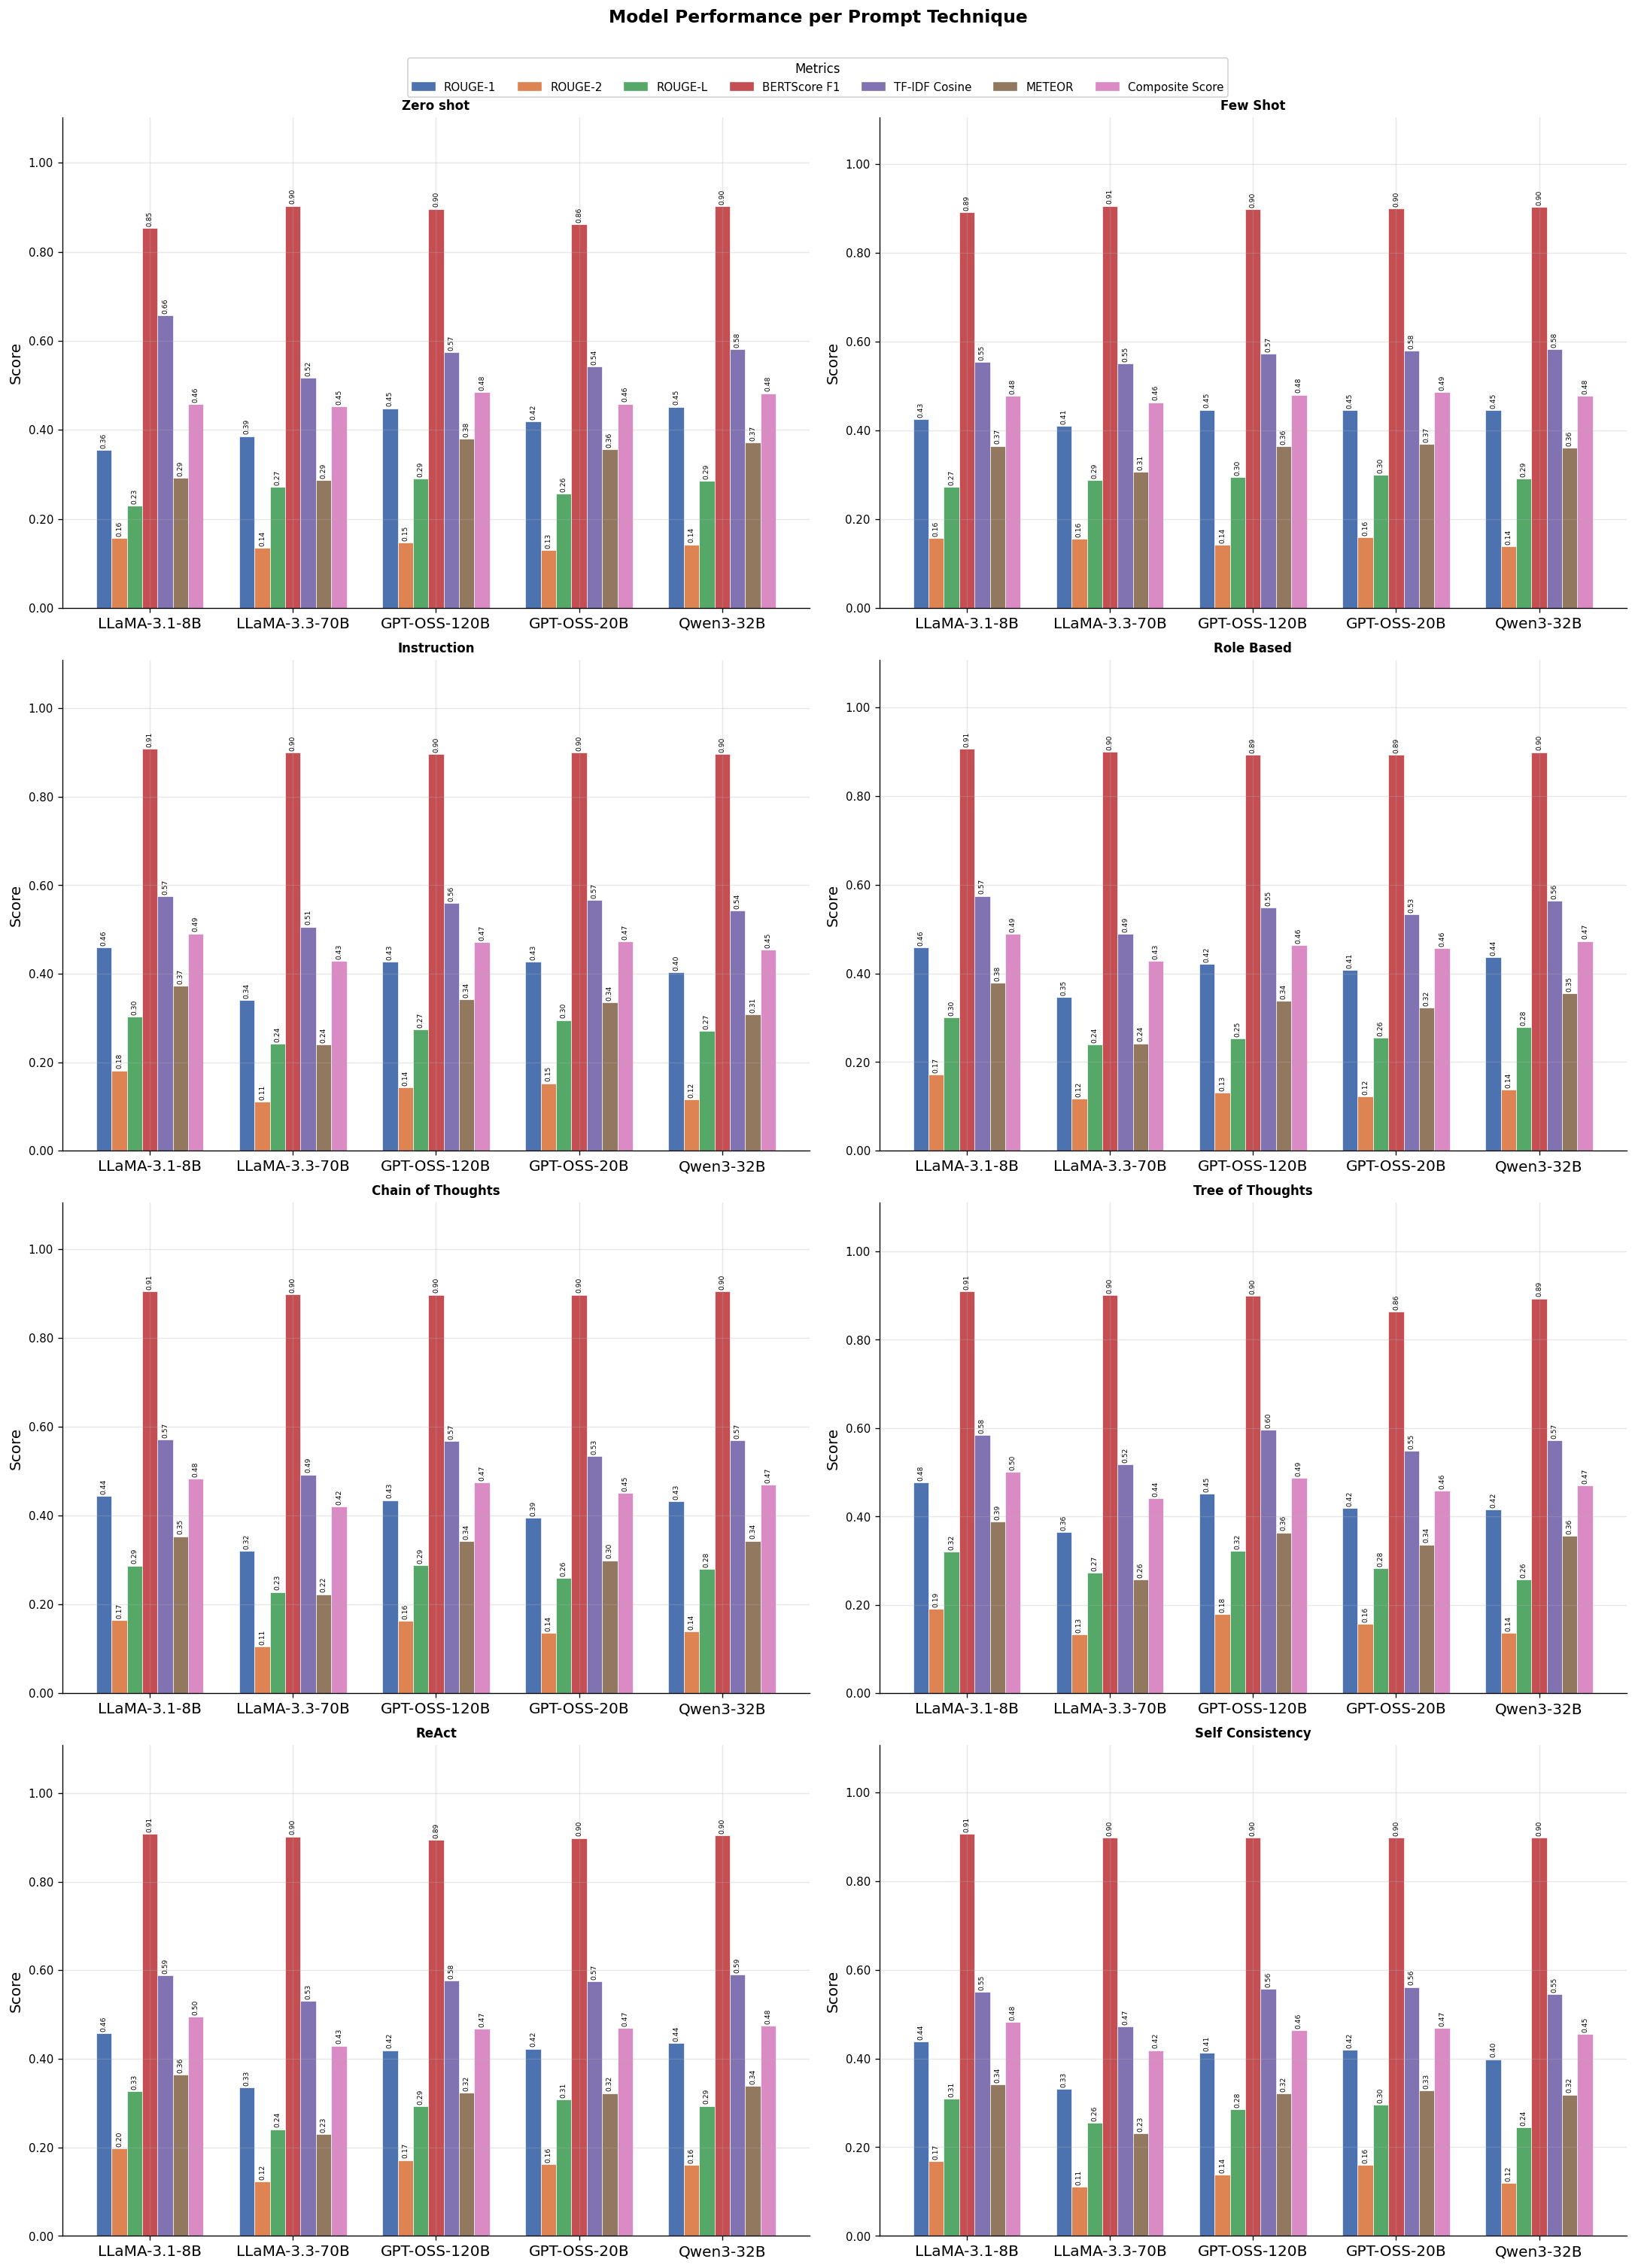

In [ ]:
# ── Colour palette for metrics ───────────────────────────────────────────────
METRIC_COLORS = [
    "#4C72B0", "#DD8452", "#55A868", "#C44E52",
    "#8172B2", "#937860", "#DA8BC3",
]


def plot_prompt_bar(ax, data, prompt, metrics):
    """X-axis = Models, grouped bars = metrics, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics)
    x          = np.arange(n_models)
    bar_w      = 0.75 / n_metrics
    offsets    = np.linspace(-(n_metrics - 1) / 2, (n_metrics - 1) / 2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(x + offsets[i], vals, width=bar_w,
                      label=METRIC_LABELS.get(metric, metric),
                      color=color, edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004, f"{val:.2f}",
                        ha="center", va="bottom", fontsize=5.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=12, ha="center")
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_bar(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
                  for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(metric_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Model Performance per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("bar_per_prompt.png", bbox_inches="tight")
plt.show()

## 4. Line Graphs: One Figure per Prompt Technique

**Structure**: One figure per prompt technique (per summary type).  
**X-axis**: LLM Models.  
**Lines**: Each metric is a separate line with markers.  
This shows how each metric varies across models for a given prompt technique.

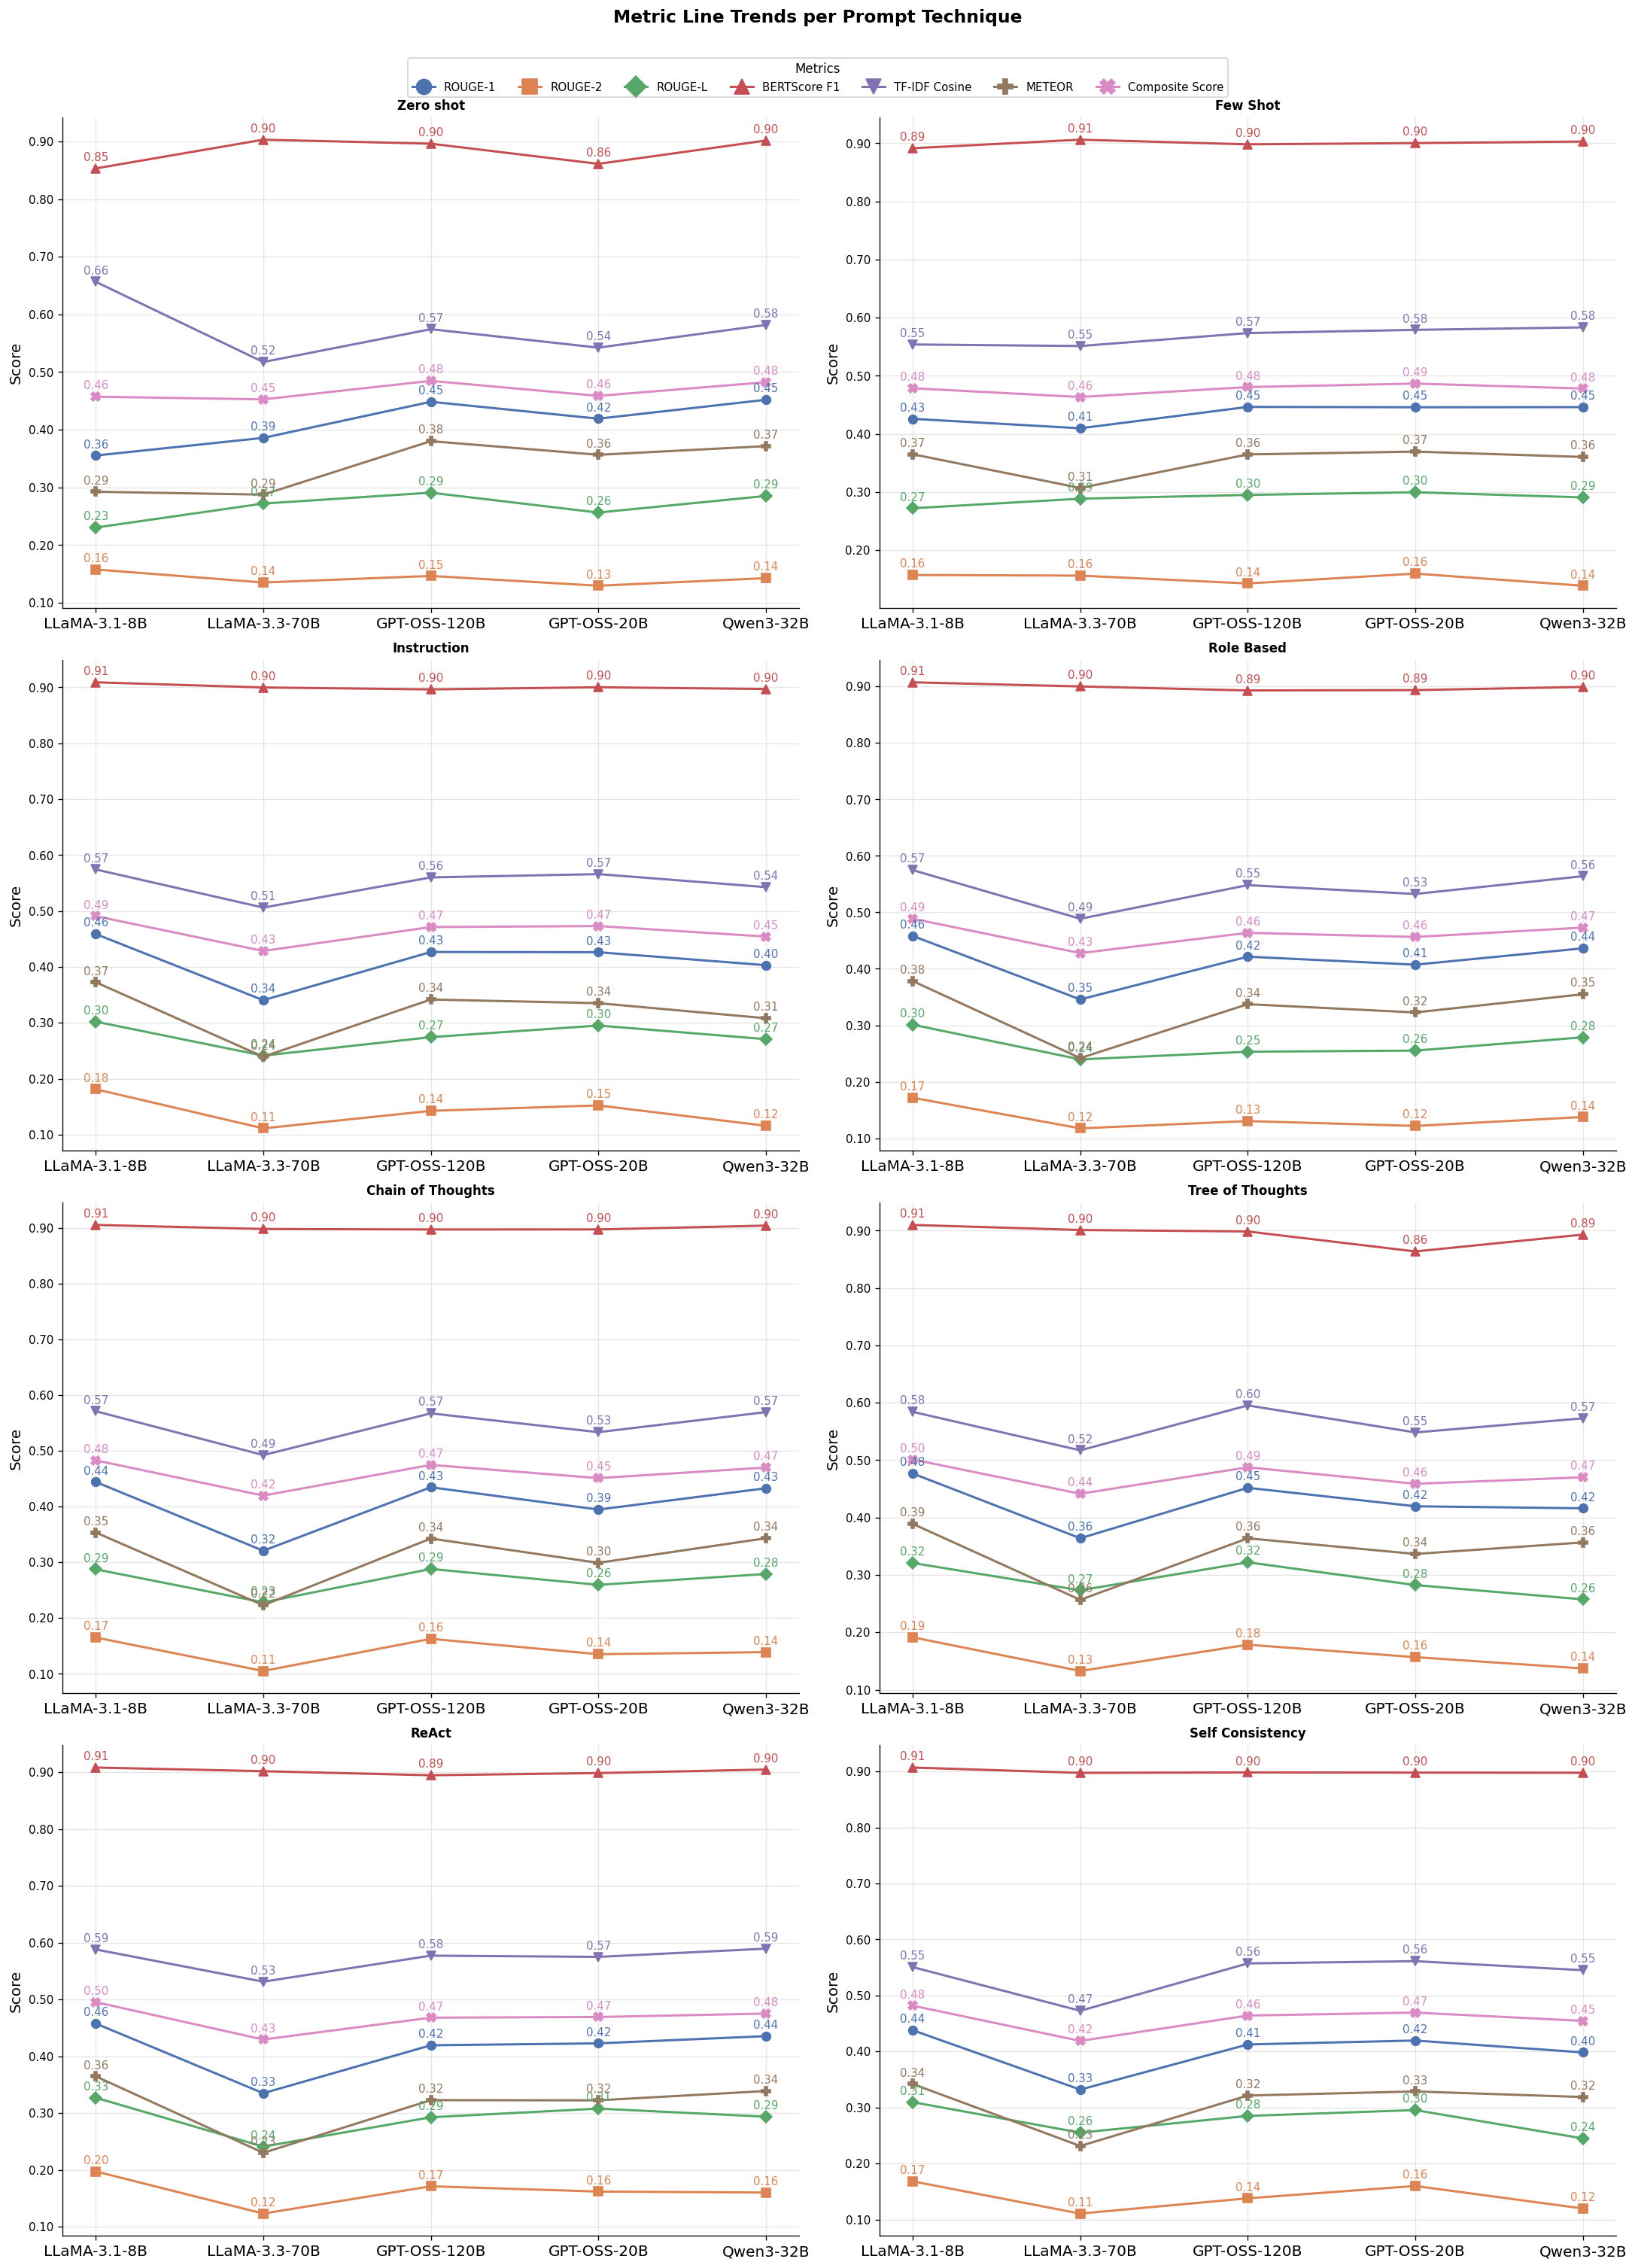

In [ ]:
MARKERS = ["o", "s", "D", "^", "v", "P", "X"]


def plot_prompt_line(ax, data, prompt, metrics):
    """X-axis = Models, one line per metric, filtered to one prompt."""
    subset = data[data["Prompting"] == prompt]
    agg = subset.groupby("Model")[metrics].mean().reindex(MODELS)

    x = np.arange(len(MODELS))
    for i, (metric, color) in enumerate(zip(metrics, METRIC_COLORS)):
        vals = agg[metric].values
        ax.plot(x, vals, marker=MARKERS[i % len(MARKERS)],
                label=METRIC_LABELS.get(metric, metric),
                color=color, linewidth=1.8, markersize=7)
        for xi, val in zip(x, vals):
            if not np.isnan(val):
                ax.annotate(f"{val:.2f}", (xi, val),
                            textcoords="offset points", xytext=(0, 6),
                            ha="center", fontsize=9, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=12, ha="center")
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))


metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols = 2
n_rows = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    plot_prompt_line(axes[idx], df, prompt, metrics_to_plot)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

line_handles = [Line2D([0], [0], color=METRIC_COLORS[i],
                       marker=MARKERS[i % len(MARKERS)],
                       linewidth=1.8, markersize=12)
                for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(line_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Metric Line Trends per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("line_per_prompt.png", bbox_inches="tight")
plt.show()

## 5. Radar Charts: Latency Profile per Model across Prompt Techniques

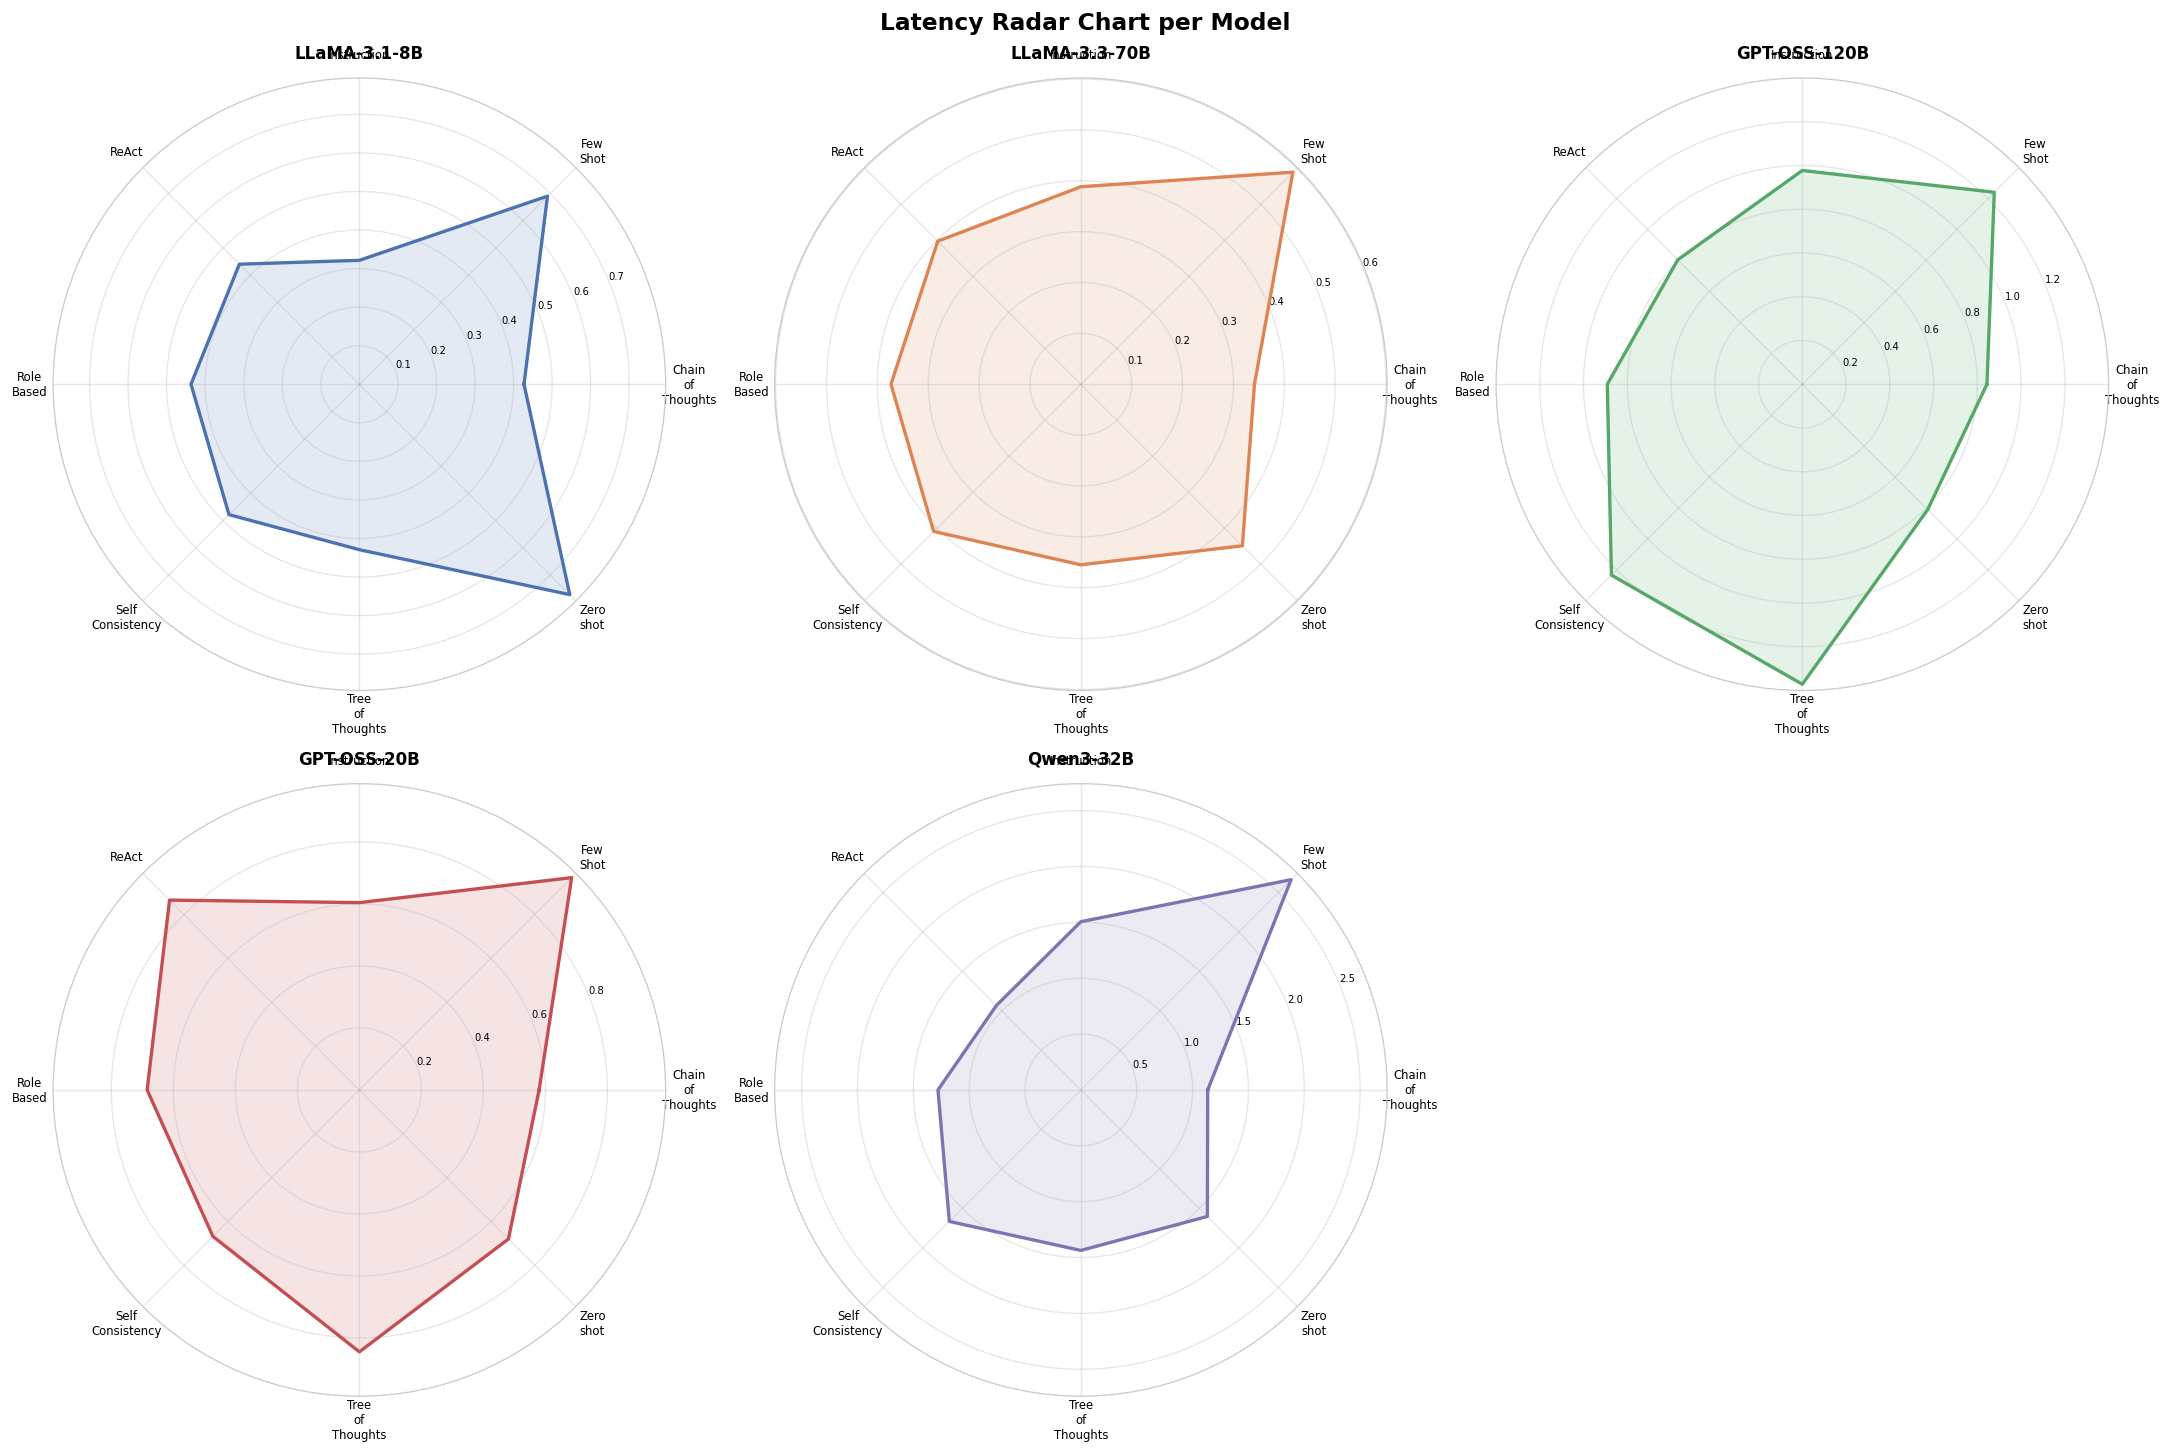

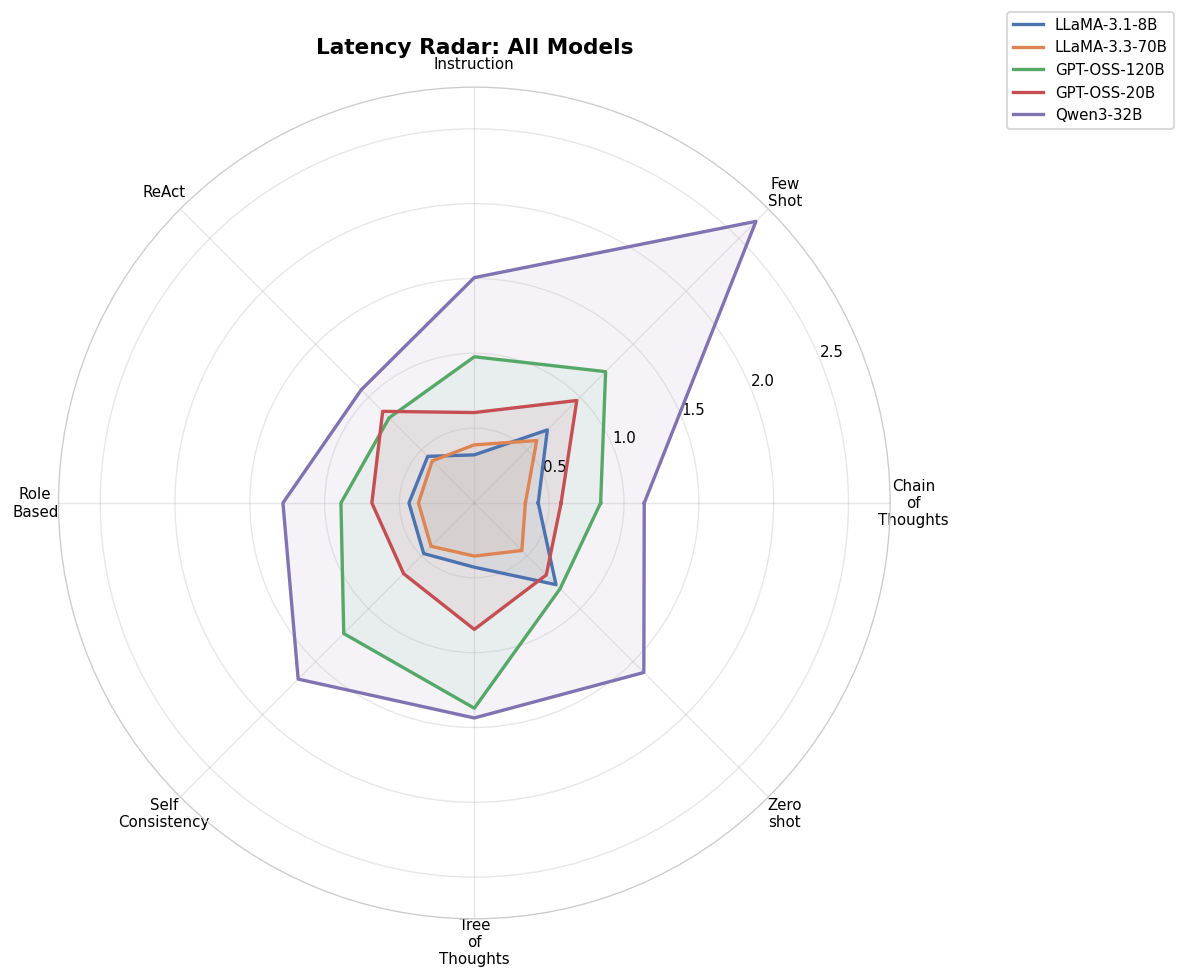

In [ ]:
def make_radar_chart(ax, values, labels, color, model_name, fill_alpha=0.15):
    """Draw a single radar (spider) chart on a polar axis."""
    n = len(labels)
    angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    values_closed = values + [values[0]]
    angles_closed = angles + [angles[0]]

    ax.plot(angles_closed, values_closed, color=color, linewidth=2)
    ax.fill(angles_closed, values_closed, color=color, alpha=fill_alpha)
    ax.set_xticks(angles)
    ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in labels], size=7)
    ax.set_title(model_name, size=10, fontweight="bold", pad=12)
    ax.spines["polar"].set_color("#cccccc")
    ax.yaxis.set_tick_params(labelsize=6)


pivot = (
    df.groupby(["Prompting", "Model"])["avg_latency_sec"]
    .mean()
    .unstack("Model")
    .reindex(columns=MODELS)
)
prompt_labels = pivot.index.tolist()

# Individual radar per model
n_cols = 3
n_rows = int(np.ceil(len(MODELS) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows),
                         subplot_kw={"polar": True}, constrained_layout=True)
axes = np.array(axes).flatten()

for i, model in enumerate(MODELS):
    vals  = pivot[model].fillna(0).tolist()
    color = MODEL_COLORS.get(model, "#888888")
    make_radar_chart(axes[i], vals, prompt_labels, color, model)

for idx in range(len(MODELS), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Latency Radar Chart per Model", fontsize=14, fontweight="bold")
plt.savefig("radar_latency.png", bbox_inches="tight")
plt.show()


# Combined radar — all models overlaid
n  = len(prompt_labels)
angles        = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angles_closed = angles + [angles[0]]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
for model in MODELS:
    vals        = pivot[model].fillna(0).tolist()
    vals_closed = vals + [vals[0]]
    color       = MODEL_COLORS.get(model, "#888888")
    ax.plot(angles_closed, vals_closed, color=color, linewidth=2, label=model)
    ax.fill(angles_closed, vals_closed, color=color, alpha=0.08)

ax.set_xticks(angles)
ax.set_xticklabels([lbl.replace(" ", "\n") for lbl in prompt_labels], size=9)
ax.spines["polar"].set_color("#cccccc")
ax.set_title("Latency Radar: All Models", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
plt.savefig("radar_latency_combined.png", bbox_inches="tight")
plt.show()

## 6. Overall Plots: Entire Summarisation Task

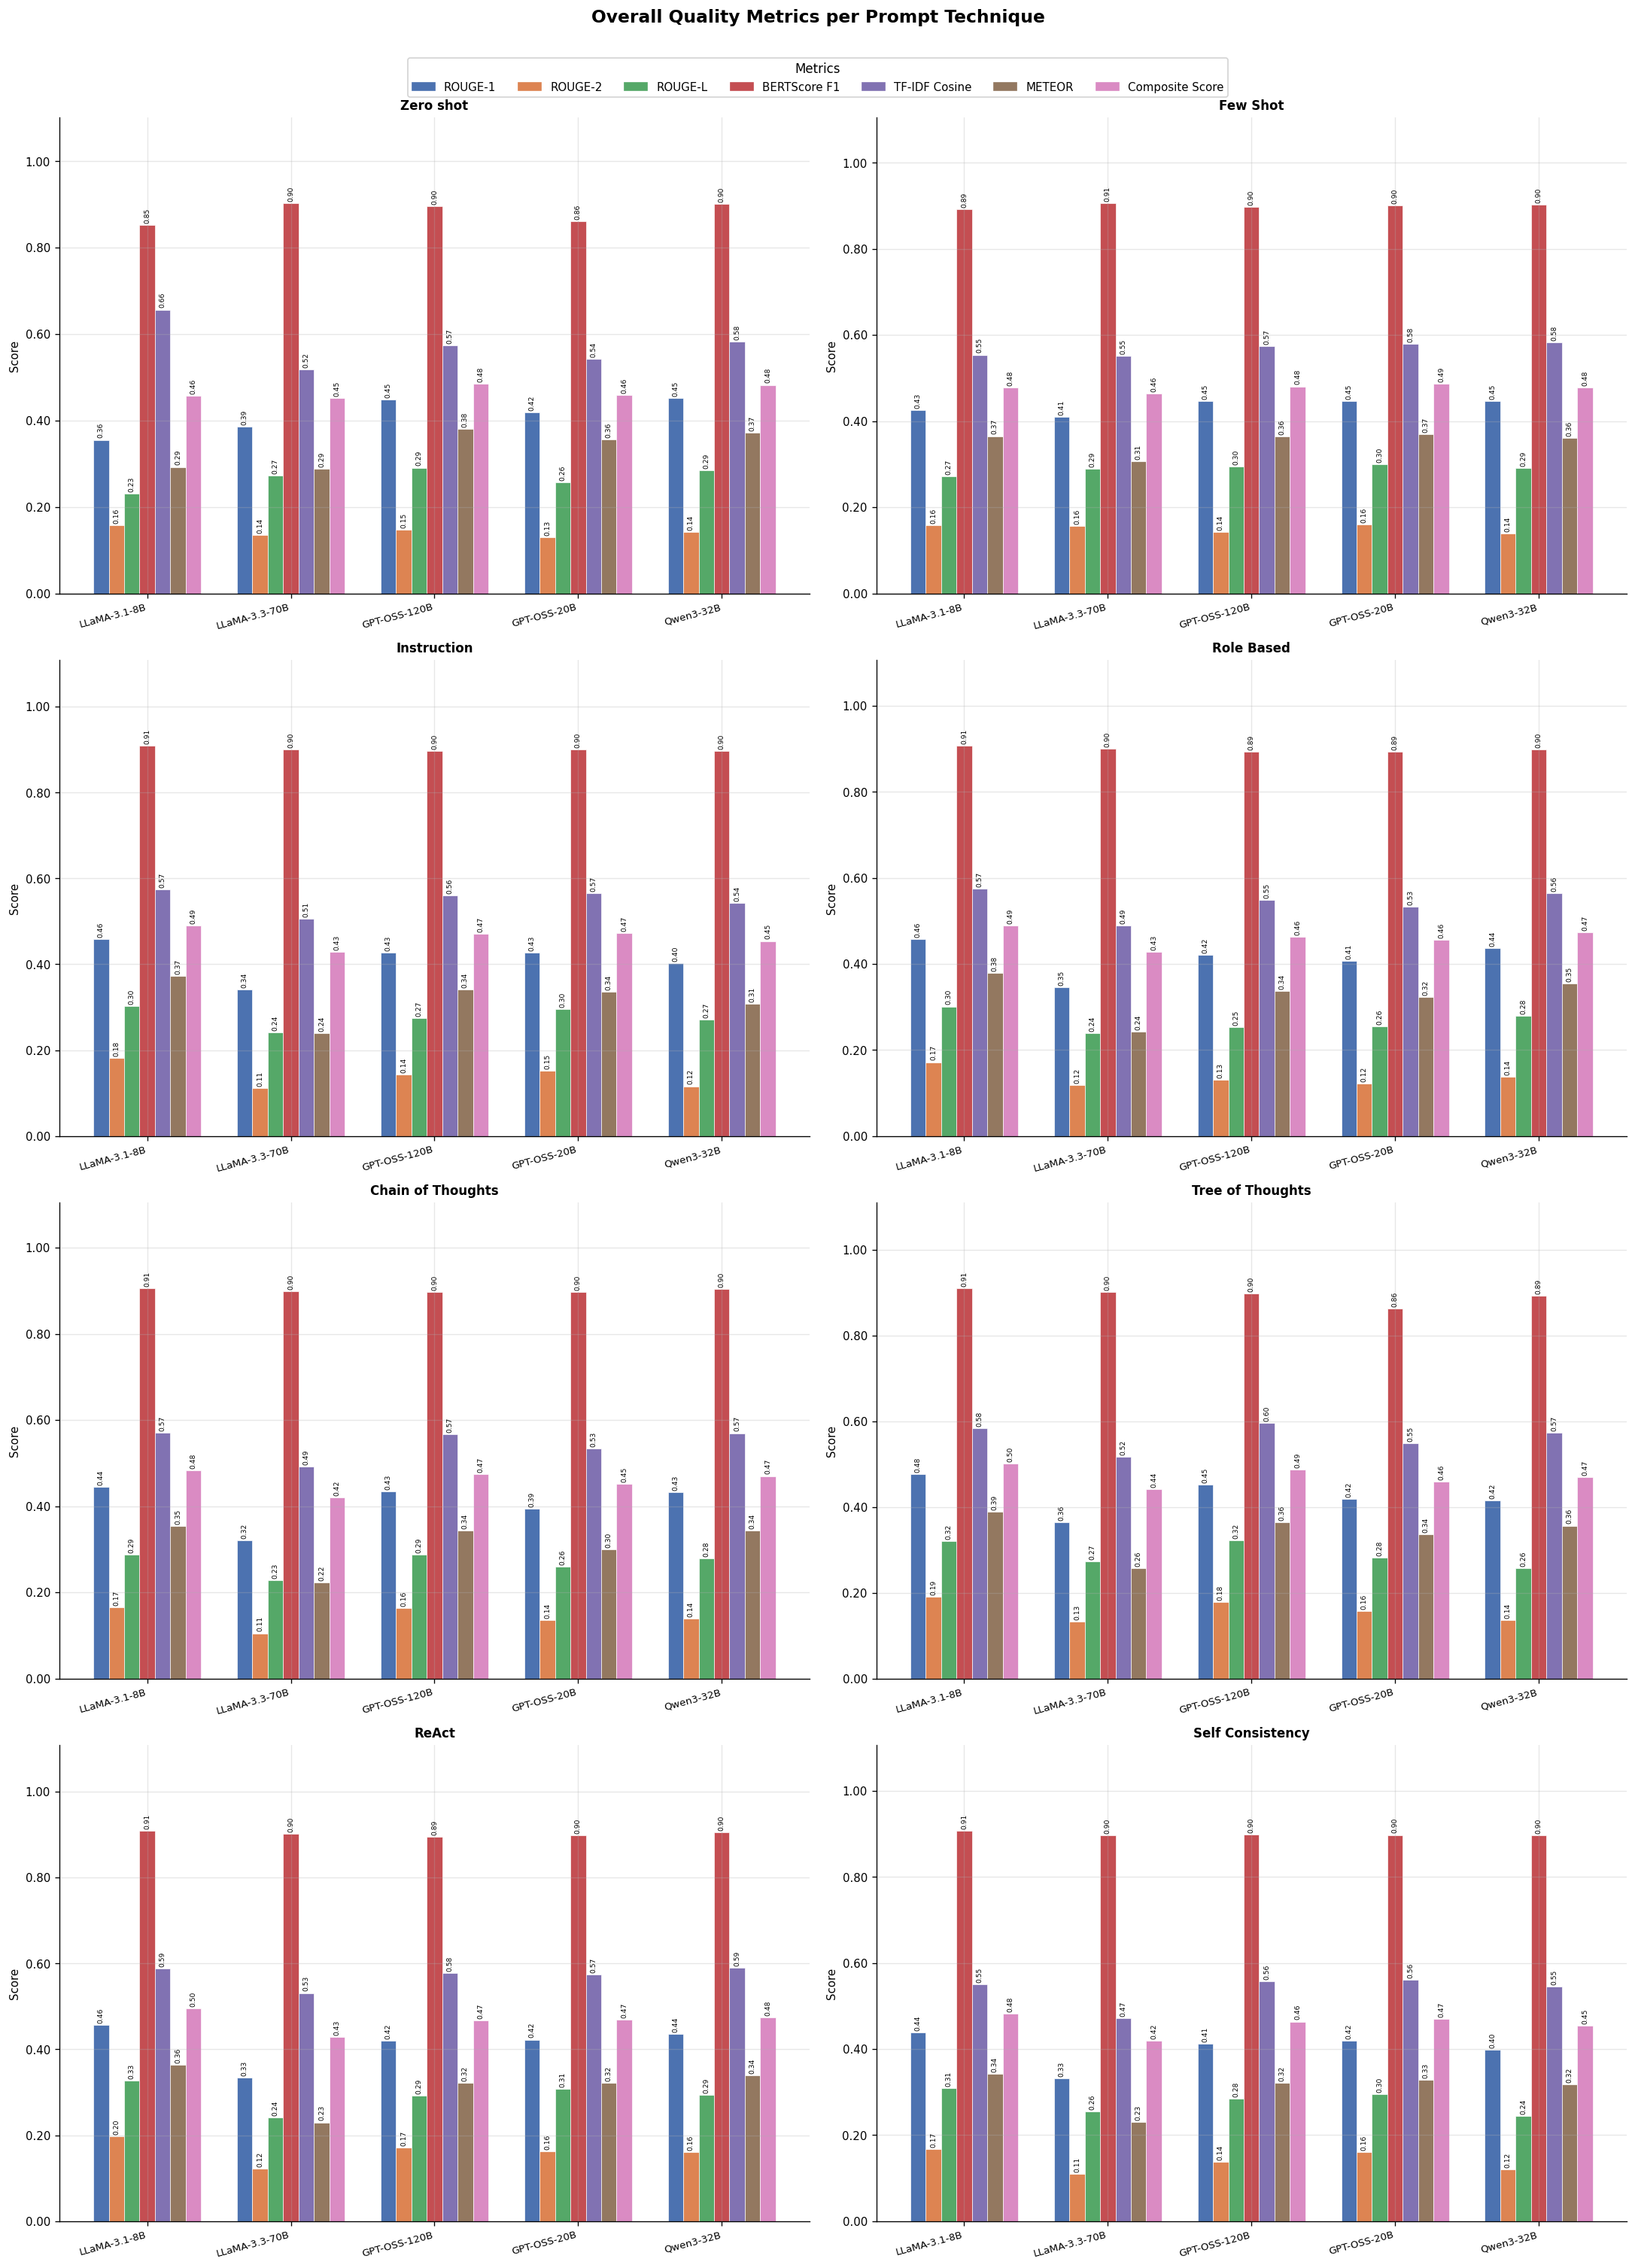

In [ ]:
metrics_to_plot = [m for m in QUALITY_METRICS if df[m].notna().any()]
n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    ax     = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg    = subset.groupby("Model")[metrics_to_plot].mean().reindex(MODELS)

    n_models  = len(MODELS)
    n_metrics = len(metrics_to_plot)
    x      = np.arange(n_models)
    bar_w  = 0.75 / n_metrics
    offsets = np.linspace(-(n_metrics-1)/2, (n_metrics-1)/2, n_metrics) * bar_w

    for i, (metric, color) in enumerate(zip(metrics_to_plot, METRIC_COLORS)):
        vals = agg[metric].values
        bars = ax.bar(x + offsets[i], vals, width=bar_w,
                      label=METRIC_LABELS.get(metric, metric),
                      color=color, edgecolor="white", linewidth=0.4)
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.004, f"{val:.2f}",
                        ha="center", va="bottom", fontsize=5.5, rotation=90)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("Score", fontsize=9)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    valid_max = agg[metrics_to_plot].max().max()
    ax.set_ylim(0, valid_max * 1.22 if not np.isnan(valid_max) else 1)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

metric_handles = [plt.Rectangle((0, 0), 1, 1, color=METRIC_COLORS[i])
                  for i in range(len(metrics_to_plot))]
metric_names = [METRIC_LABELS.get(m, m) for m in metrics_to_plot]
fig.legend(metric_handles, metric_names, loc="upper center",
           ncol=len(metrics_to_plot), fontsize=9,
           bbox_to_anchor=(0.5, 1.02), frameon=True,
           title="Metrics", title_fontsize=10)
fig.suptitle("Overall Quality Metrics per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("overall_quality_bar.png", bbox_inches="tight")
plt.show()

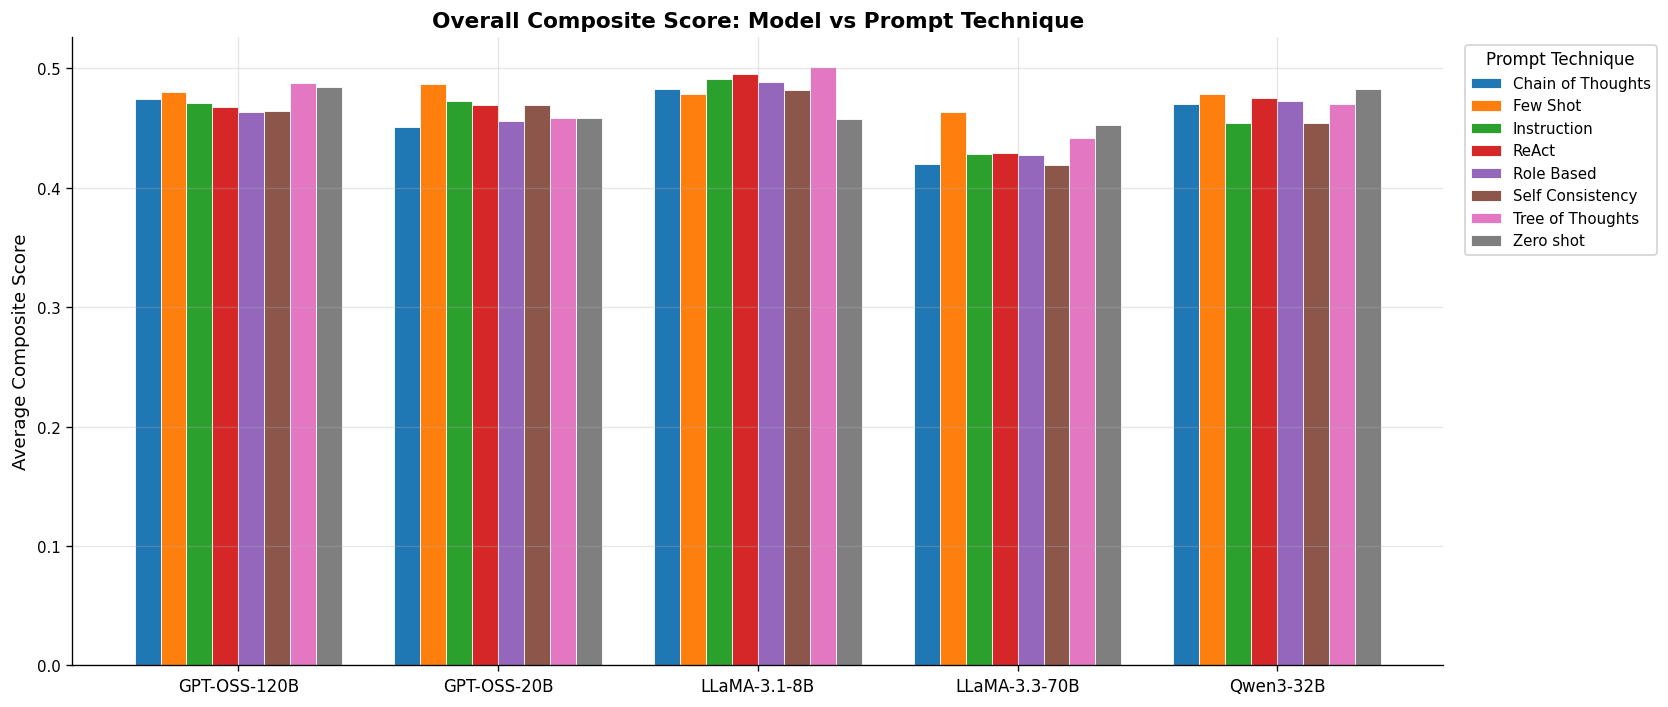

In [ ]:
# ── Overall Composite Score: Model vs Prompt heatmap-style bar ───────────────
comp_pivot = (
    df.groupby(["Model", "Prompting"])["composite_score"]
    .mean()
    .unstack("Prompting")
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(comp_pivot))
n_prompts = len(comp_pivot.columns)
width = 0.8 / n_prompts
prompt_colors = sns.color_palette("tab10", n_prompts)

for i, prompt in enumerate(comp_pivot.columns):
    offsets = (i - n_prompts / 2 + 0.5) * width
    ax.bar(
        x + offsets,
        comp_pivot[prompt].values,
        width=width,
        label=prompt,
        color=prompt_colors[i],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(comp_pivot.index, fontsize=10)
ax.set_ylabel("Average Composite Score", fontsize=11)
ax.set_title(
    "Overall Composite Score: Model vs Prompt Technique",
    fontsize=13,
    fontweight="bold",
)
ax.legend(
    title="Prompt Technique",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("overall_composite_bar.png", bbox_inches="tight")
plt.show()

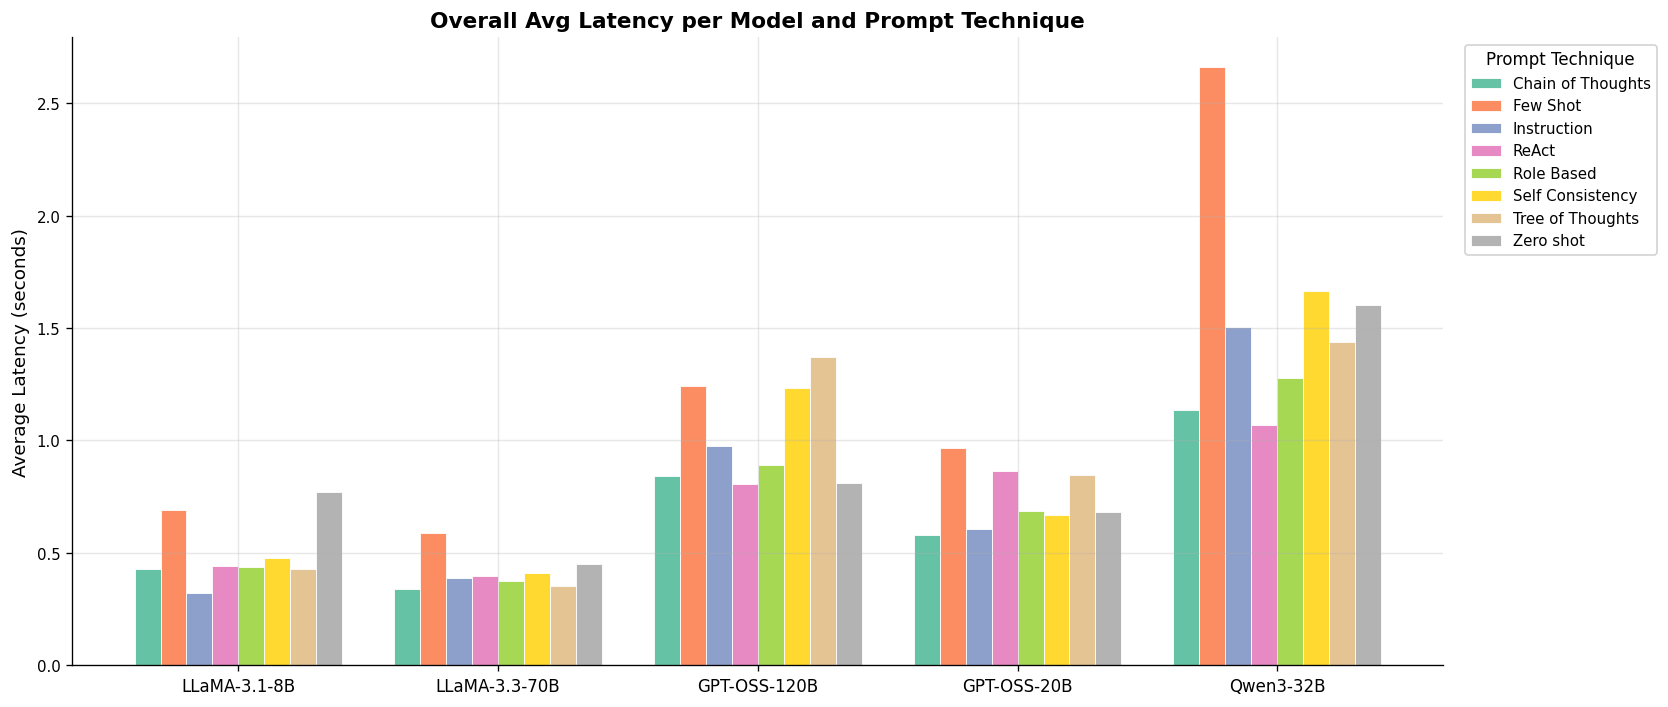

In [ ]:
# ── Overall Latency: bar chart across models and prompts ─────────────────────
lat_pivot = (
    df.groupby(["Model", "Prompting"])["avg_latency_sec"]
    .mean()
    .unstack("Prompting")
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(lat_pivot))
n_prompts = len(lat_pivot.columns)
width = 0.8 / n_prompts
lat_colors = sns.color_palette("Set2", n_prompts)

for i, prompt in enumerate(lat_pivot.columns):
    offsets = (i - n_prompts / 2 + 0.5) * width
    ax.bar(
        x + offsets,
        lat_pivot[prompt].values,
        width=width,
        label=prompt,
        color=lat_colors[i],
        edgecolor="white",
        linewidth=0.5,
    )

ax.set_xticks(x)
ax.set_xticklabels(lat_pivot.index, fontsize=10)
ax.set_ylabel("Average Latency (seconds)", fontsize=11)
ax.set_title(
    "Overall Avg Latency per Model and Prompt Technique",
    fontsize=13,
    fontweight="bold",
)
ax.legend(
    title="Prompt Technique",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=9,
)
plt.tight_layout()
plt.savefig("overall_latency_bar.png", bbox_inches="tight")
plt.show()

## 7. Heatmaps: Composite Score and Latency Matrices

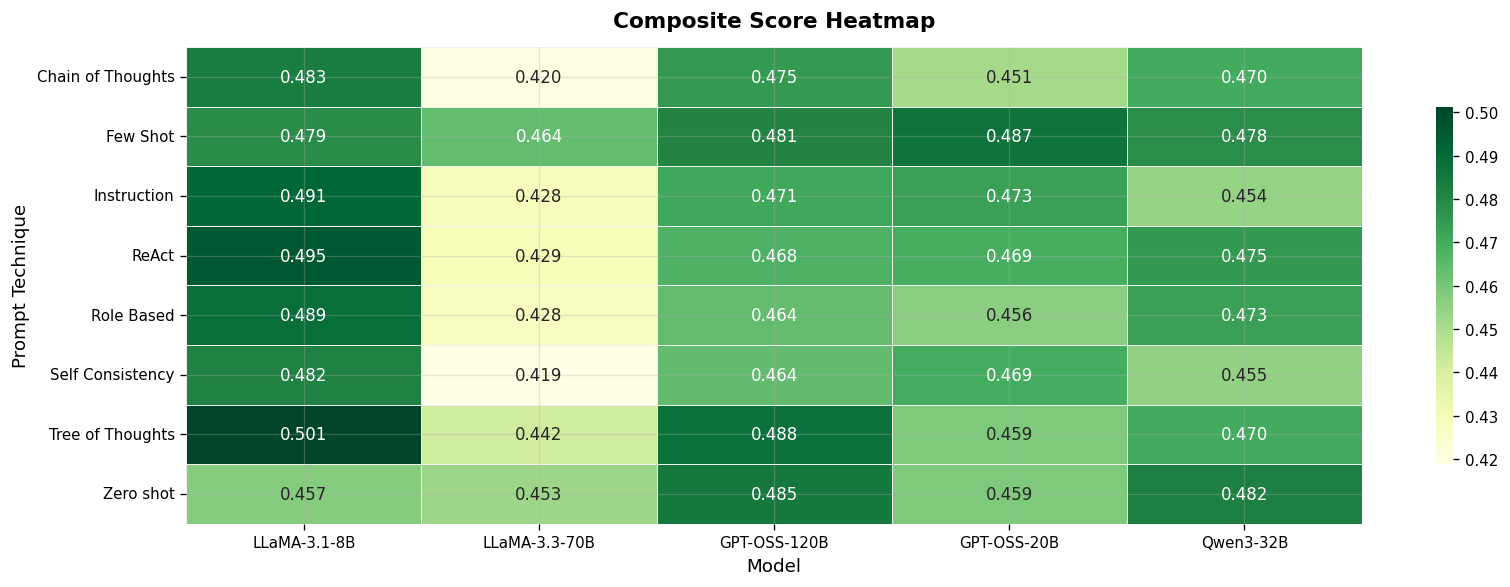

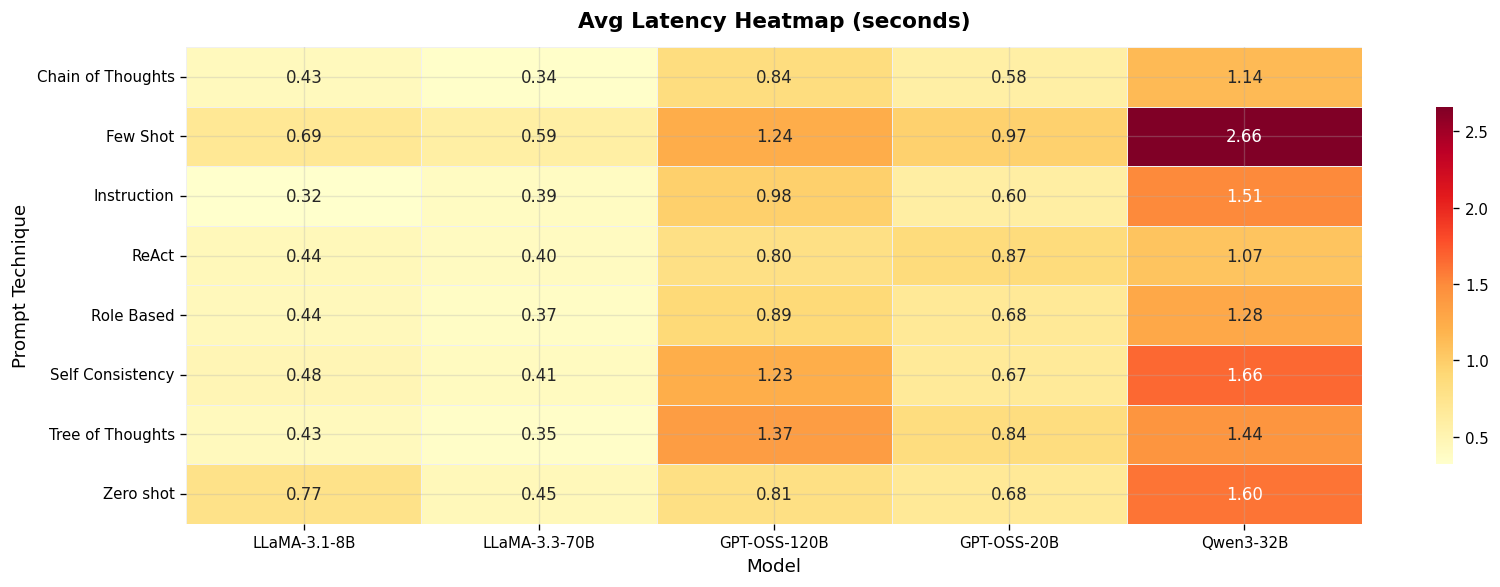

In [ ]:
def plot_heatmap(pivot_table, title, cmap, fmt=".3f", figsize=(14, 5), save_path=None):
    """Render a labelled heatmap."""
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(pivot_table, annot=True, fmt=fmt, cmap=cmap,
                linewidths=0.5, linecolor="#f0f0f0", ax=ax,
                cbar_kws={"shrink": 0.75})
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Model", fontsize=11)
    ax.set_ylabel("Prompt Technique", fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()


comp_heat = (df.groupby(["Prompting", "Model"])["composite_score"]
             .mean().unstack("Model").reindex(columns=MODELS))
plot_heatmap(comp_heat, "Composite Score Heatmap", "YlGn",
             save_path="heatmap_composite.png")

lat_heat = (df.groupby(["Prompting", "Model"])["avg_latency_sec"]
            .mean().unstack("Model").reindex(columns=MODELS))
plot_heatmap(lat_heat, "Avg Latency Heatmap (seconds)", "YlOrRd",
             fmt=".2f", save_path="heatmap_latency.png")

## 8. Performance Dashboard: Composite Score vs Latency (Efficiency Scatter)

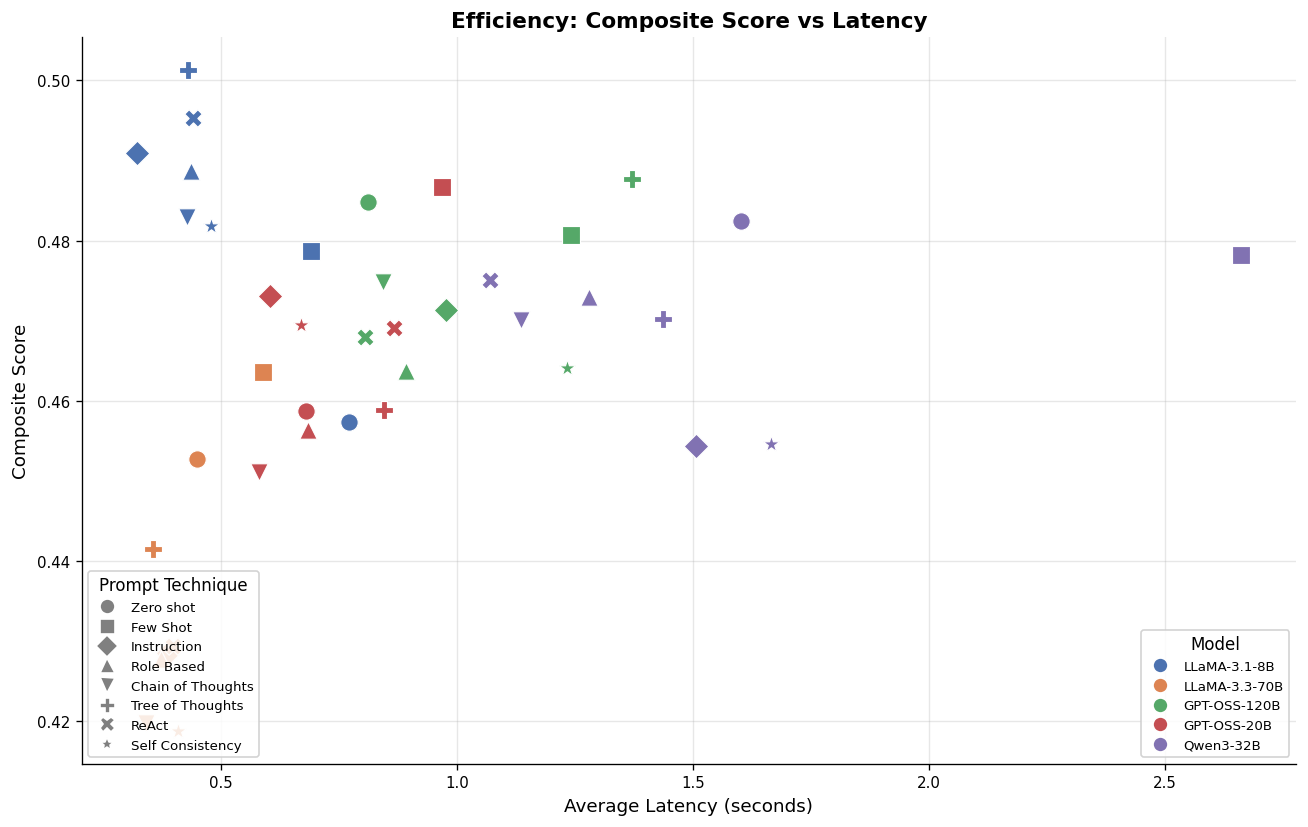

In [ ]:
PROMPT_MARKERS = {p: m for p, m in zip(PROMPTS, ["o", "s", "D", "^", "v", "P", "X", "*"])}

agg = (df.groupby(["Model", "Prompting"])[["composite_score", "avg_latency_sec"]]
       .mean().reset_index())

fig, ax = plt.subplots(figsize=(11, 7))
for _, row in agg.iterrows():
    ax.scatter(row["avg_latency_sec"], row["composite_score"],
               color=MODEL_COLORS.get(row["Model"], "gray"),
               marker=PROMPT_MARKERS.get(row["Prompting"], "o"),
               s=110, edgecolors="white", linewidths=0.7, zorder=3)

model_handles = [Line2D([0], [0], marker="o", color="w",
                        markerfacecolor=MODEL_COLORS.get(m, "gray"),
                        markersize=9, label=m) for m in MODELS]
prompt_handles = [Line2D([0], [0], marker=PROMPT_MARKERS[p], color="w",
                         markerfacecolor="gray", markersize=9, label=p)
                  for p in PROMPTS if p in PROMPT_MARKERS]

leg1 = ax.legend(handles=model_handles, title="Model", loc="lower right", fontsize=8)
ax.add_artist(leg1)
ax.legend(handles=prompt_handles, title="Prompt Technique", loc="lower left", fontsize=8)
ax.set_xlabel("Average Latency (seconds)", fontsize=11)
ax.set_ylabel("Composite Score", fontsize=11)
ax.set_title("Efficiency: Composite Score vs Latency", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("scatter_efficiency.png", bbox_inches="tight")
plt.show()

## 9. Box Plots: Score Distributions Across Prompt Techniques

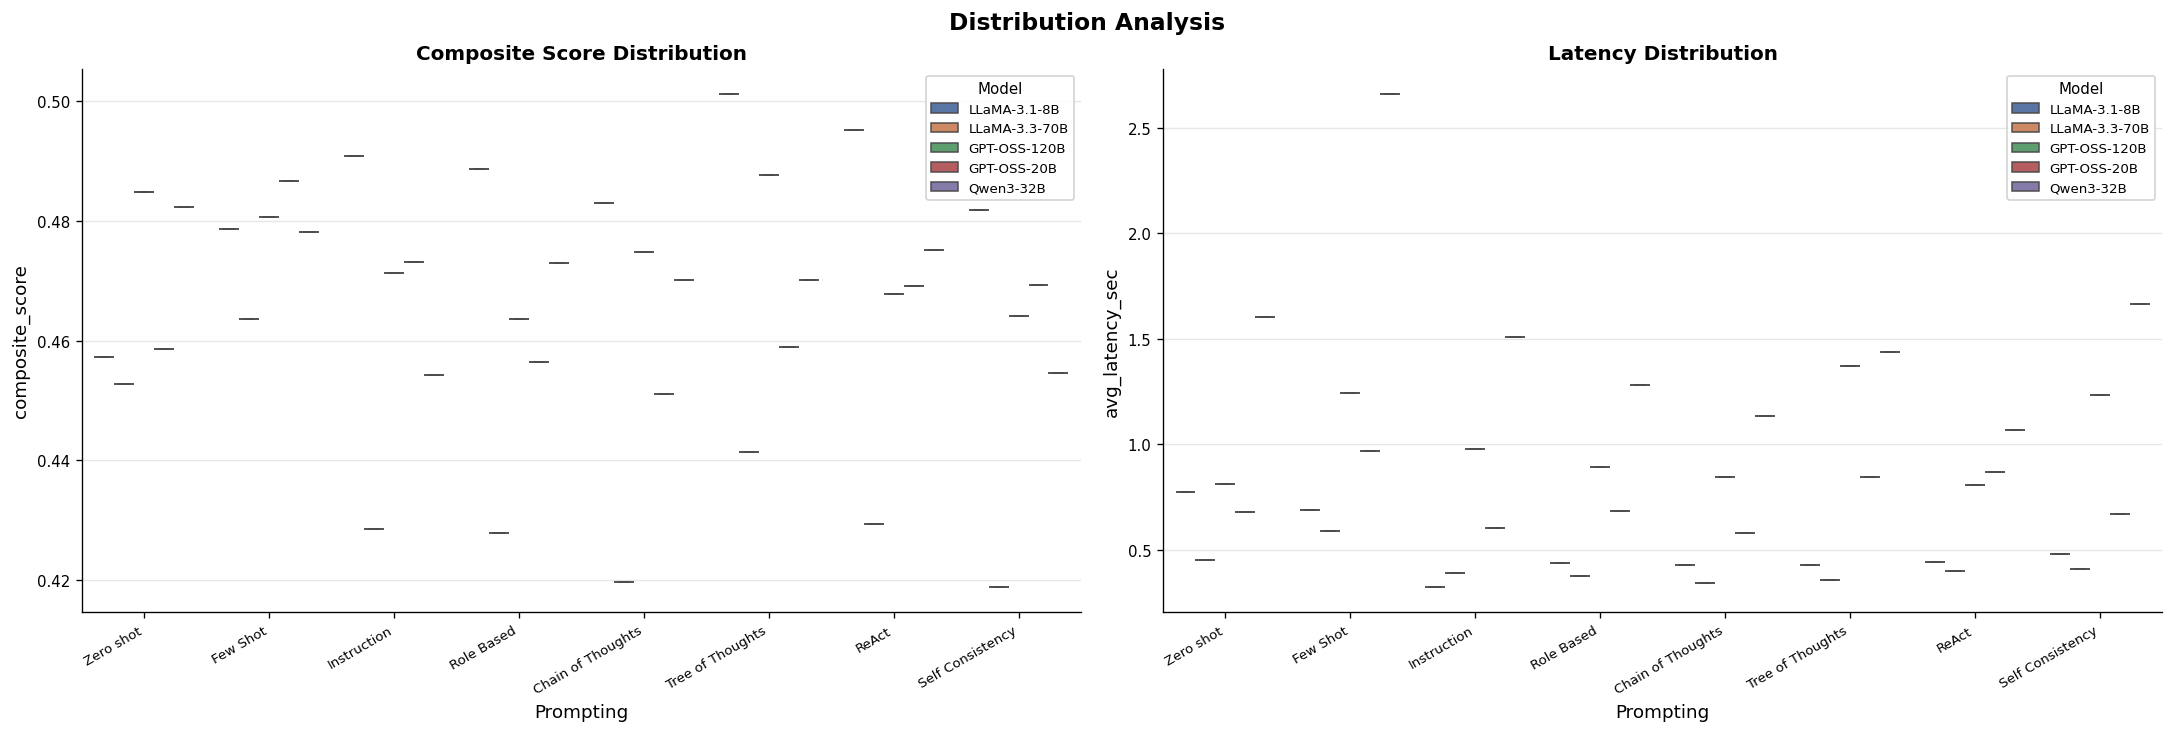

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)

sns.boxplot(data=df, x="Prompting", y="composite_score", hue="Model",
            palette=MODEL_COLORS, ax=axes[0], linewidth=0.9, fliersize=3)
axes[0].set_title("Composite Score Distribution", fontsize=12, fontweight="bold")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[0].legend(title="Model", fontsize=8, title_fontsize=9)

sns.boxplot(data=df, x="Prompting", y="avg_latency_sec", hue="Model",
            palette=MODEL_COLORS, ax=axes[1], linewidth=0.9, fliersize=3)
axes[1].set_title("Latency Distribution", fontsize=12, fontweight="bold")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right", fontsize=8)
axes[1].legend(title="Model", fontsize=8, title_fontsize=9)

fig.suptitle("Distribution Analysis", fontsize=14, fontweight="bold")
plt.savefig("boxplot.png", bbox_inches="tight")
plt.show()

## 10. Multi-Metric Comparison: ROUGE Trio Side-by-Side

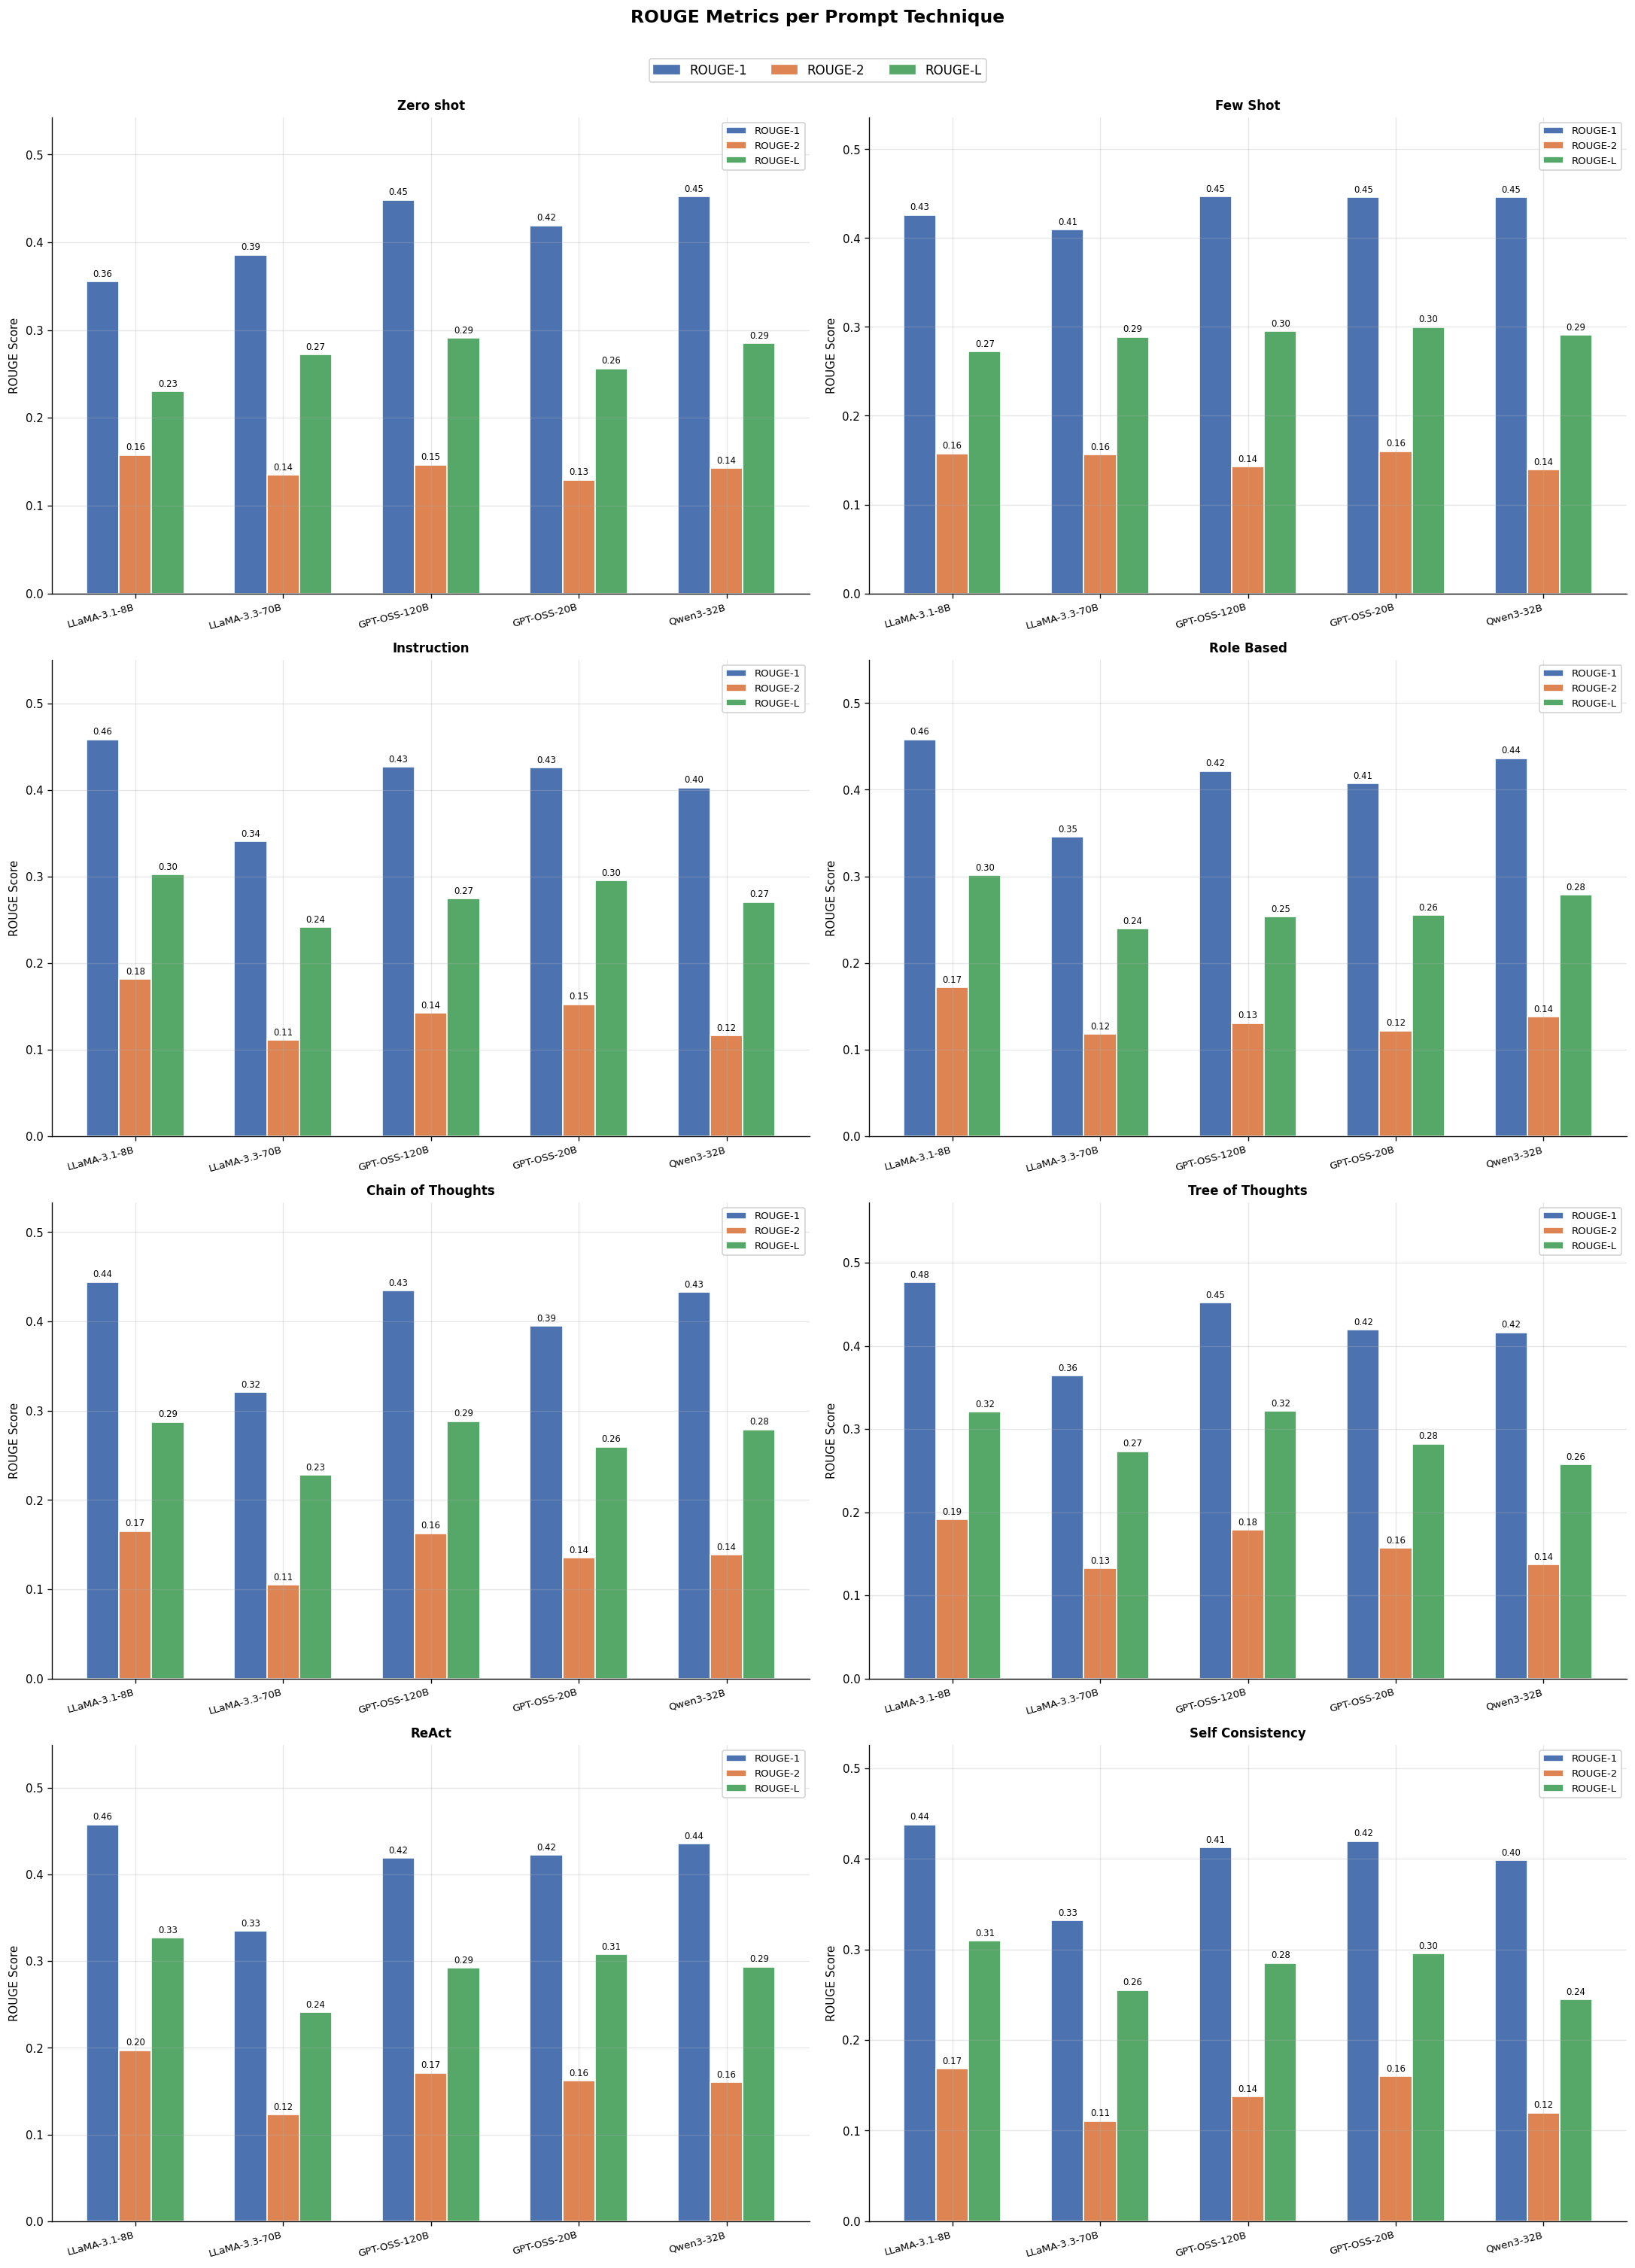

In [ ]:
rouge_metrics = [m for m in ["avg_rouge1", "avg_rouge2", "avg_rougeL"] if df[m].notna().any()]
rouge_colors  = ["#4C72B0", "#DD8452", "#55A868"]

n_prompts = len(PROMPTS)
n_cols    = 2
n_rows    = int(np.ceil(n_prompts / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows), constrained_layout=True)
axes = np.array(axes).flatten()

for idx, prompt in enumerate(PROMPTS):
    ax     = axes[idx]
    subset = df[df["Prompting"] == prompt]
    agg    = subset.groupby("Model")[rouge_metrics].mean().reindex(MODELS)
    x      = np.arange(len(MODELS))
    bar_w  = 0.22
    offsets = np.array([-1, 0, 1]) * bar_w

    for i, (metric, color) in enumerate(zip(rouge_metrics, rouge_colors)):
        vals = agg[metric].values
        bars = ax.bar(x + offsets[i], vals, width=bar_w,
                      label=METRIC_LABELS.get(metric, metric),
                      color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.003, f"{val:.2f}",
                        ha="center", va="bottom", fontsize=7)

    ax.set_xticks(x)
    ax.set_xticklabels(MODELS, fontsize=8, rotation=15, ha="right")
    ax.set_ylabel("ROUGE Score", fontsize=9)
    ax.set_title(f"{prompt}", fontsize=10, fontweight="bold")
    valid_max = agg[rouge_metrics].max().max()
    ax.set_ylim(0, valid_max * 1.2 if not np.isnan(valid_max) else 1)
    ax.legend(fontsize=8)

for idx in range(n_prompts, len(axes)):
    axes[idx].set_visible(False)

rouge_handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in rouge_colors]
rouge_names   = [METRIC_LABELS.get(m, m) for m in rouge_metrics]
fig.legend(rouge_handles, rouge_names, loc="upper center", ncol=3,
           fontsize=10, bbox_to_anchor=(0.5, 1.02), frameon=True)
fig.suptitle("ROUGE Metrics per Prompt Technique",
             fontsize=14, fontweight="bold", y=1.04)
plt.savefig("rouge_per_prompt.png", bbox_inches="tight")
plt.show()

## 11. Best Model per Metric (Composite Score)

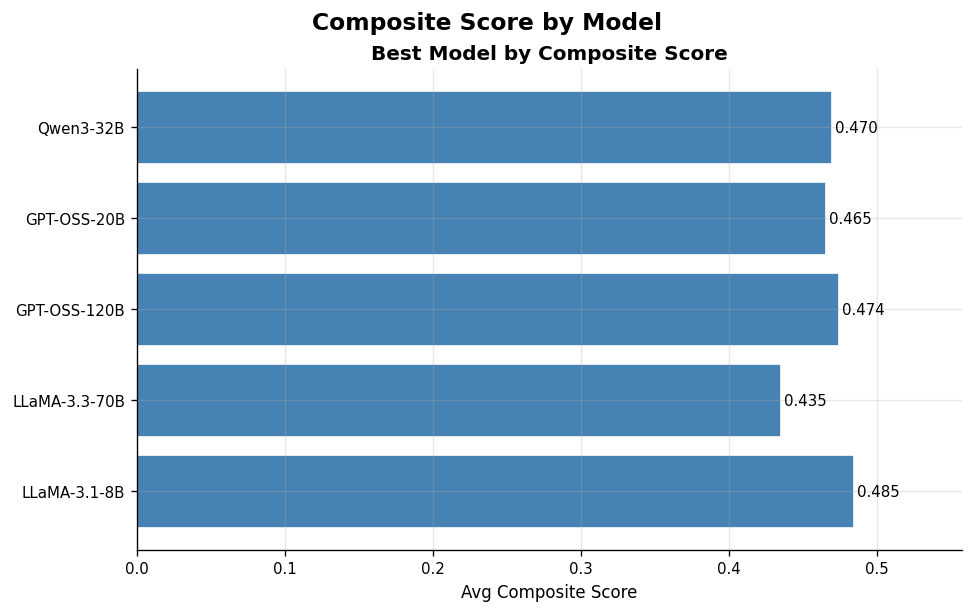

In [ ]:
model_scores = (
    df.groupby("Model")["composite_score"]
    .mean()
    .reindex(MODELS)
)

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)
bars = ax.barh(
    model_scores.index,
    model_scores.values,
    color="steelblue",
    edgecolor="white",
)
for bar, val in zip(bars, model_scores.values):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=9,
    )
ax.set_title("Best Model by Composite Score", fontsize=12, fontweight="bold")
ax.set_xlabel("Avg Composite Score", fontsize=10)
ax.set_xlim(0, model_scores.max() * 1.15)
fig.suptitle(
    "Composite Score by Model",
    fontsize=14,
    fontweight="bold",
)
plt.savefig("summary_type_comparison.png", bbox_inches="tight")
plt.show()


## 12. Latency Breakdown: Min / Avg / Max per Model

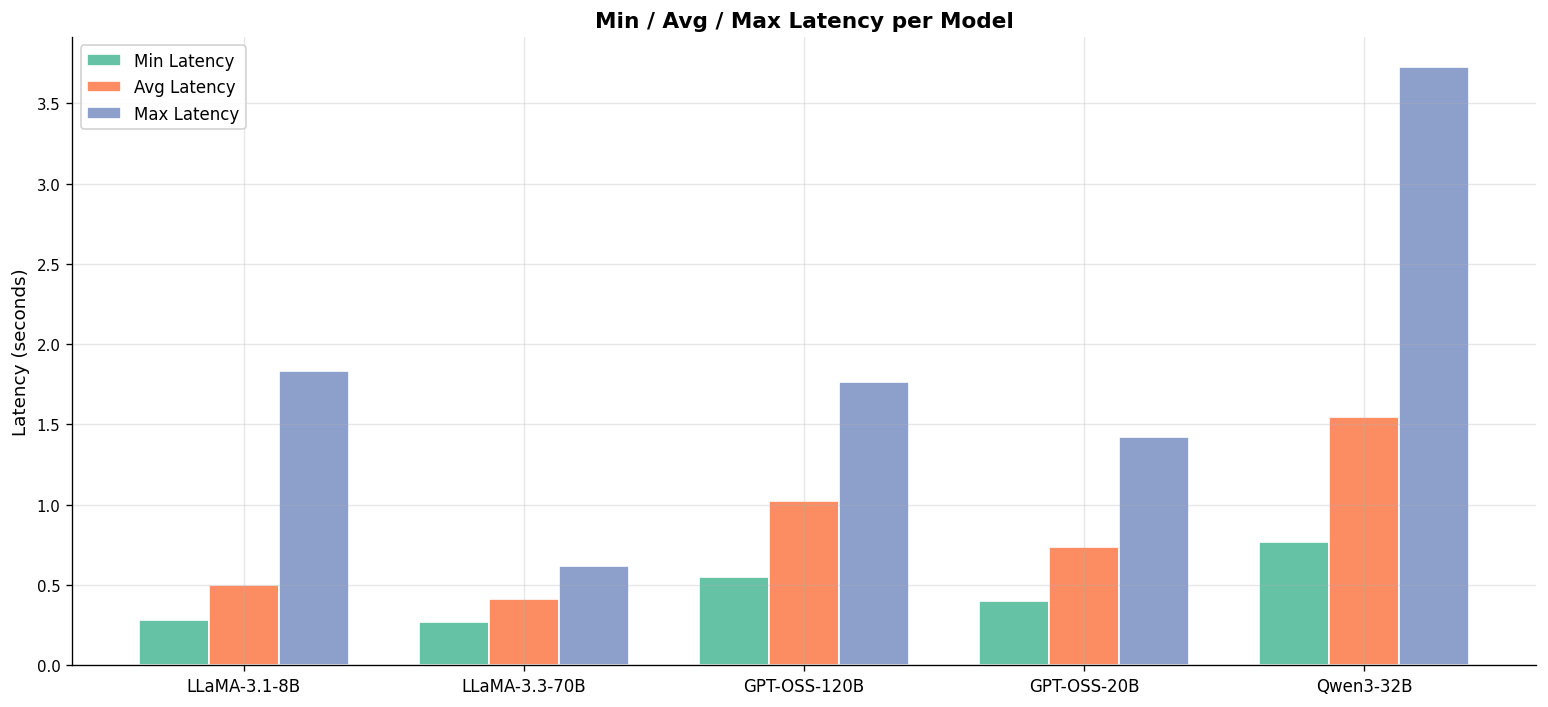

In [ ]:
lat_agg = (df.groupby("Model")[["min_latency_sec", "avg_latency_sec", "max_latency_sec"]]
           .mean().reindex(MODELS))

x = np.arange(len(MODELS))
width         = 0.25
lat_bar_colors = ["#66C2A5", "#FC8D62", "#8DA0CB"]
lat_labels_map = ["Min Latency", "Avg Latency", "Max Latency"]

fig, ax = plt.subplots(figsize=(13, 6))
for i, (col, color, label) in enumerate(zip(
        ["min_latency_sec", "avg_latency_sec", "max_latency_sec"],
        lat_bar_colors, lat_labels_map)):
    ax.bar(x + (i - 1) * width, lat_agg[col].values, width=width,
           label=label, color=color, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(MODELS, fontsize=10)
ax.set_ylabel("Latency (seconds)", fontsize=11)
ax.set_title("Min / Avg / Max Latency per Model", fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("latency_breakdown.png", bbox_inches="tight")
plt.show()

## 13. Novelty, Compression, and Readability Analysis

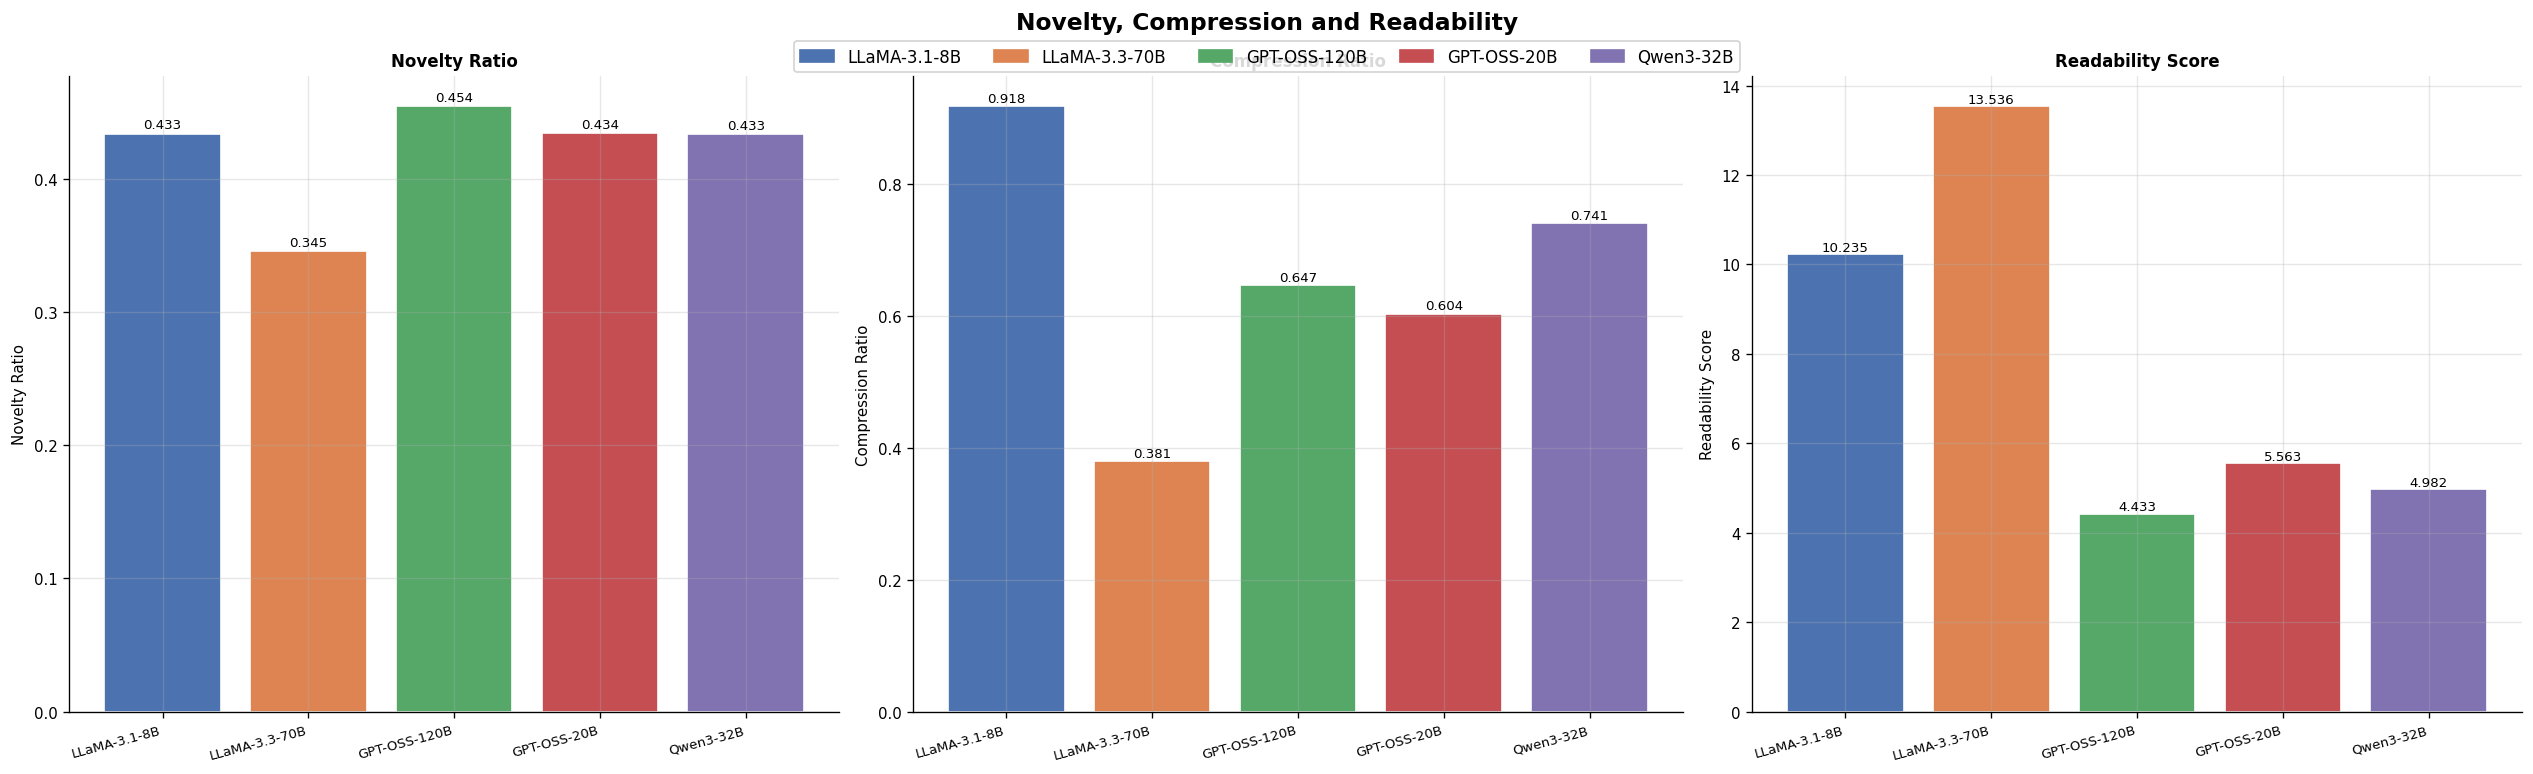

In [ ]:
def plot_bar_metric_by_model(data, metric, ax):
    """Bar chart of one metric by model."""
    agg    = data.groupby("Model")[metric].mean().reindex(MODELS)
    colors = [MODEL_COLORS.get(m, "gray") for m in agg.index]
    bars   = ax.bar(agg.index, agg.values, color=colors, edgecolor="white")
    for bar, val in zip(bars, agg.values):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.002, f"{val:.3f}",
                    ha="center", va="bottom", fontsize=8)
    ax.set_ylabel(METRIC_LABELS.get(metric, metric), fontsize=9)
    ax.set_title(METRIC_LABELS.get(metric, metric), fontsize=10, fontweight="bold")
    ax.set_xticklabels(agg.index, rotation=15, ha="right", fontsize=8)


available_metrics = [m for m in OTHER_METRICS if df[m].notna().any()]

if available_metrics:
    fig, axes = plt.subplots(1, len(available_metrics),
                             figsize=(7 * len(available_metrics), 6),
                             constrained_layout=True)
    if len(available_metrics) == 1:
        axes = [axes]
    for ax, metric in zip(axes, available_metrics):
        plot_bar_metric_by_model(df, metric, ax)

    handles = [plt.Rectangle((0, 0), 1, 1, color=MODEL_COLORS.get(m, "gray")) for m in MODELS]
    fig.legend(handles, MODELS, loc="upper center", ncol=len(MODELS),
               fontsize=10, bbox_to_anchor=(0.5, 1.02))
    fig.suptitle("Novelty, Compression and Readability",
                 fontsize=14, fontweight="bold", y=1.05)
    plt.savefig("other_metrics.png", bbox_inches="tight")
    plt.show()
else:
    print("No novelty/compression/readability metrics available.")

## 14. Correlation Heatmap: All Metrics

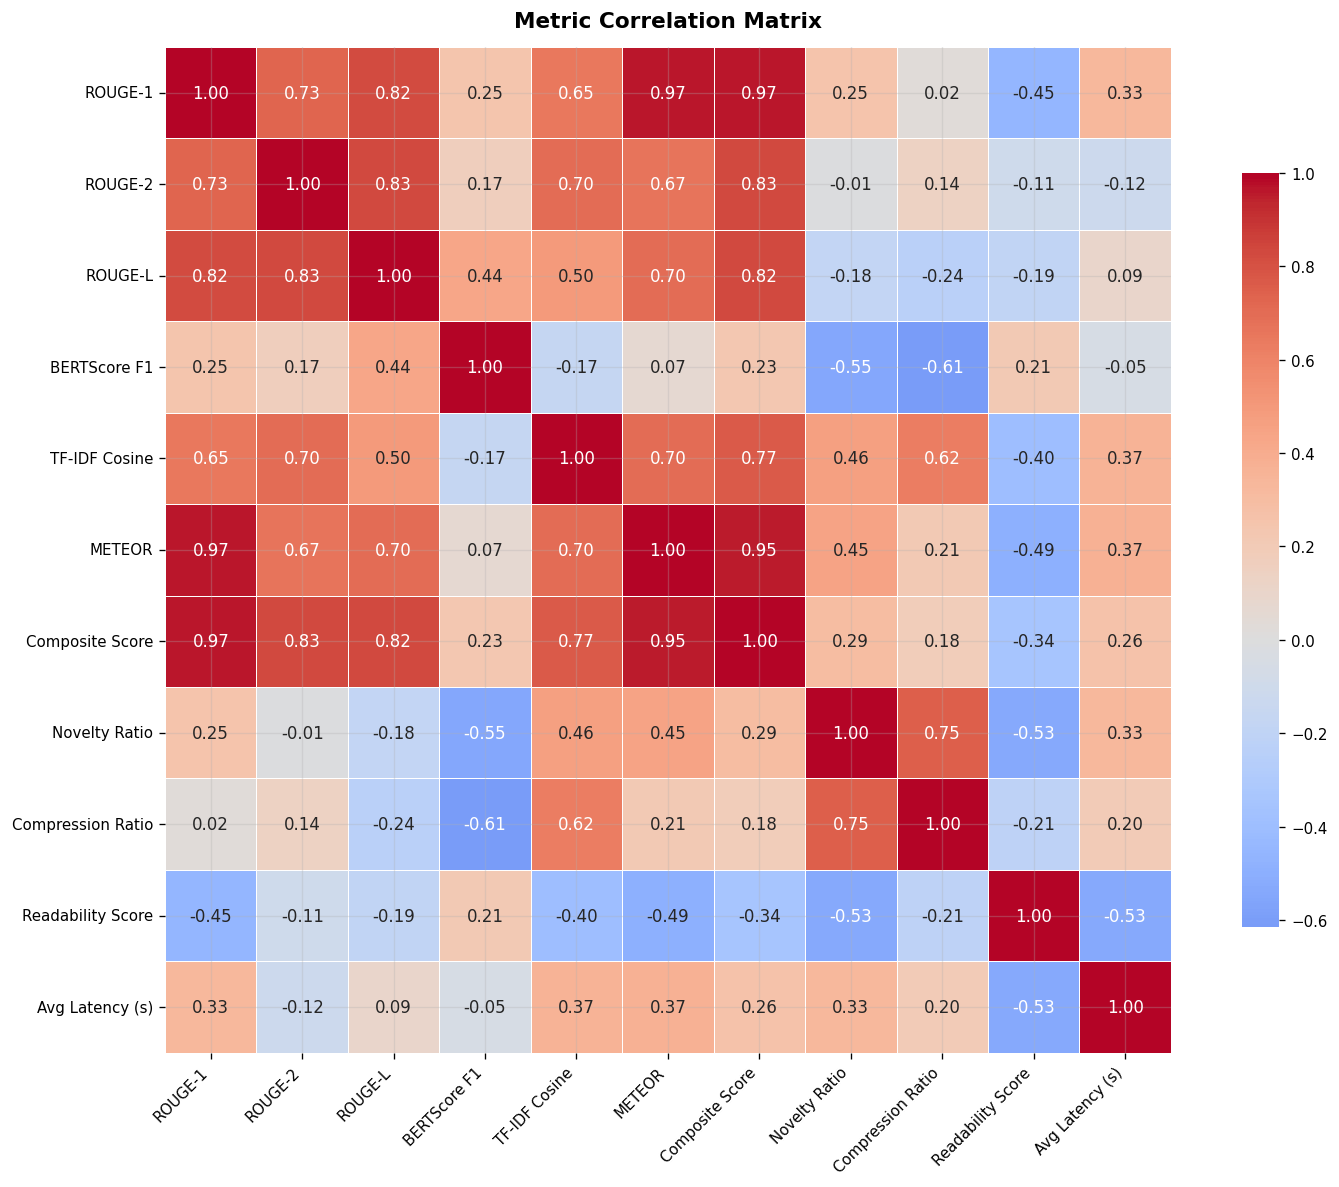

In [ ]:
all_metrics = QUALITY_METRICS + OTHER_METRICS + ["avg_latency_sec"]
available = [m for m in all_metrics if df[m].notna().sum() > 10]

corr_matrix = df[available].corr()
labels = [METRIC_LABELS.get(m, m) for m in available]

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"shrink": 0.75},
)
ax.set_title(
    "Metric Correlation Matrix",
    fontsize=13,
    fontweight="bold",
    pad=12,
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", bbox_inches="tight")
plt.show()

## 15. Rankings: Top Models and Prompt Techniques

In [ ]:
ranking_metrics    = ["composite_score", "avg_rouge1", "avg_bert_f1", "avg_latency_sec"]
available_ranking  = [m for m in ranking_metrics if df[m].notna().sum() > 0]
agg_ascending      = {m: (m == "avg_latency_sec") for m in available_ranking}

print("=" * 70)
print("MODEL RANKINGS (mean across all prompts)")
print("=" * 70)
model_rank = df.groupby("Model")[available_ranking].mean().round(4)
for metric in available_ranking:
    model_rank[f"Rank_{metric}"] = model_rank[metric].rank(
        ascending=agg_ascending[metric]).astype(int)
print(model_rank.to_string())

print("\n" + "=" * 70)
print("PROMPT TECHNIQUE RANKINGS (mean across all models)")
print("=" * 70)
prompt_rank = df.groupby("Prompting")[available_ranking].mean().round(4)
for metric in available_ranking:
    prompt_rank[f"Rank_{metric}"] = prompt_rank[metric].rank(
        ascending=agg_ascending[metric]).astype(int)
print(prompt_rank.to_string())

print("\n" + "=" * 70)
print("BEST COMBINATION: Model x Prompt (by Composite Score)")
print("=" * 70)
best_combos = (df.groupby(["Model", "Prompting"])["composite_score"]
               .mean().reset_index()
               .sort_values("composite_score", ascending=False)
               .head(15).reset_index(drop=True))
best_combos.index += 1
print(best_combos.to_string())

MODEL RANKINGS (mean across all prompts)
               composite_score  avg_rouge1  avg_bert_f1  avg_latency_sec  Rank_composite_score  Rank_avg_rouge1  Rank_avg_bert_f1  Rank_avg_latency_sec
Model                                                                                                                                                  
GPT-OSS-120B            0.4744      0.4327       0.8965           1.0217                     2                2                 4                     4
GPT-OSS-20B             0.4654      0.4194       0.8891           0.7370                     4                4                 5                     3
LLaMA-3.1-8B            0.4846      0.4394       0.8989           0.4994                     1                1                 3                     2
LLaMA-3.3-70B           0.4352      0.3542       0.9009           0.4129                     5                5                 1                     1
Qwen3-32B               0.4697      0.4276     

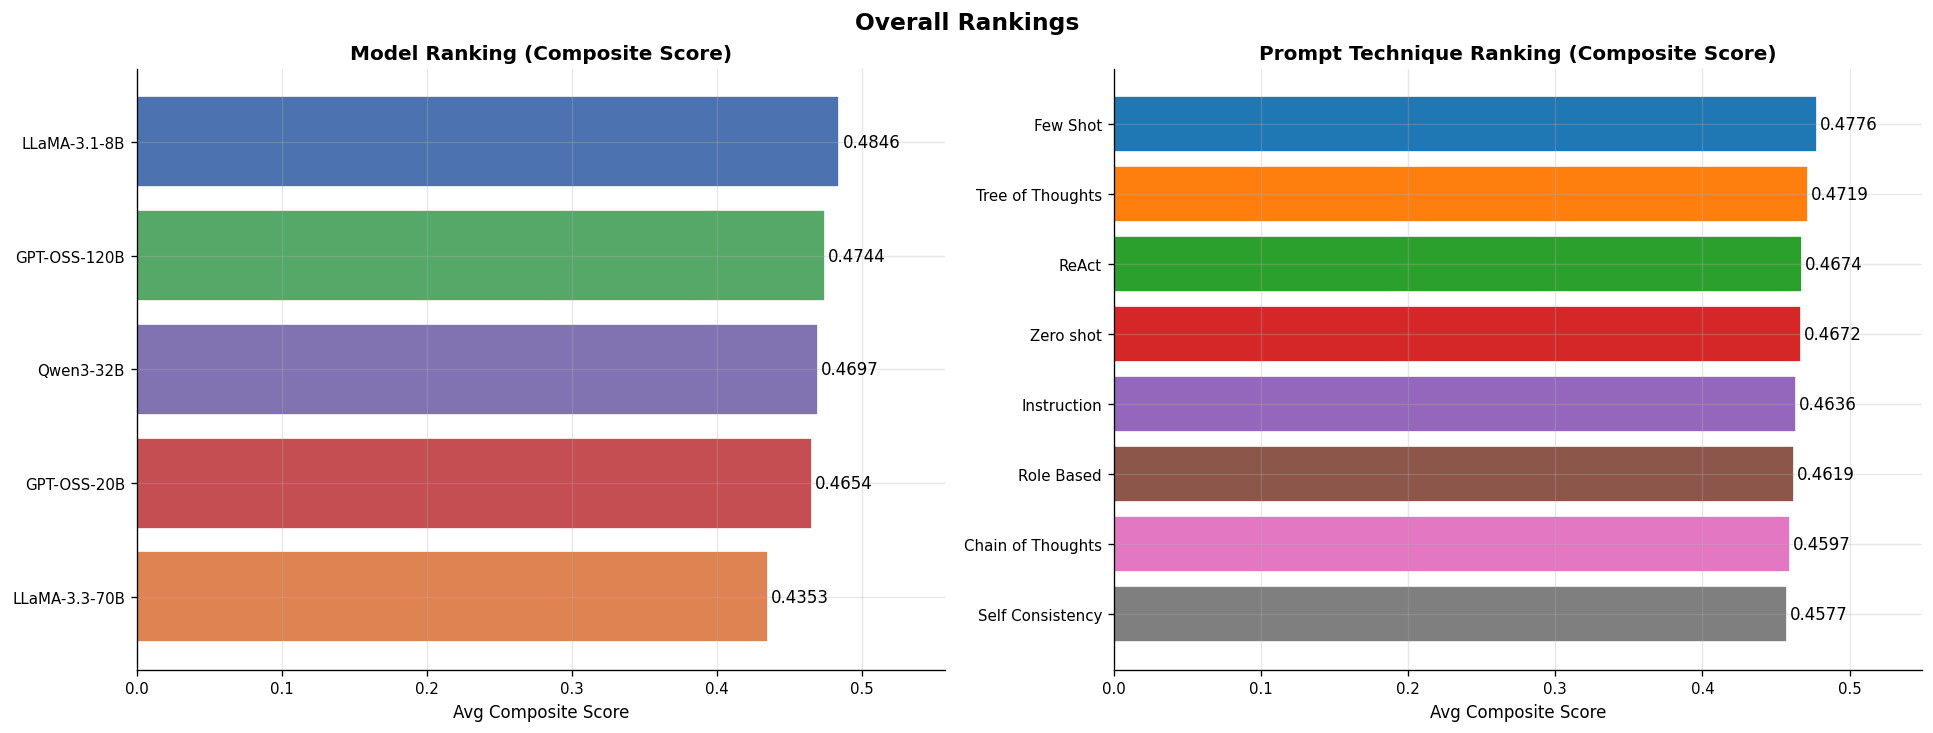

In [ ]:
model_composite  = (df.groupby("Model")["composite_score"]
                    .mean().reindex(MODELS).sort_values(ascending=False))
prompt_composite = (df.groupby("Prompting")["composite_score"]
                    .mean().sort_values(ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

bar_colors = [MODEL_COLORS.get(m, "gray") for m in model_composite.index]
bars = axes[0].barh(model_composite.index[::-1], model_composite.values[::-1],
                    color=bar_colors[::-1], edgecolor="white")
for bar, val in zip(bars, model_composite.values[::-1]):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=10)
axes[0].set_title("Model Ranking (Composite Score)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Avg Composite Score", fontsize=10)
axes[0].set_xlim(0, model_composite.max() * 1.15)

prompt_colors = sns.color_palette("tab10", len(prompt_composite))
bars2 = axes[1].barh(prompt_composite.index[::-1], prompt_composite.values[::-1],
                     color=prompt_colors[::-1], edgecolor="white")
for bar, val in zip(bars2, prompt_composite.values[::-1]):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f"{val:.4f}", va="center", fontsize=10)
axes[1].set_title("Prompt Technique Ranking (Composite Score)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Avg Composite Score", fontsize=10)
axes[1].set_xlim(0, prompt_composite.max() * 1.15)

fig.suptitle("Overall Rankings", fontsize=14, fontweight="bold")
plt.savefig("overall_rankings.png", bbox_inches="tight")
plt.show()

## 16. Summary Statistics Table

In [ ]:
summary_metrics   = ["avg_rouge1", "avg_rouge2", "avg_rougeL",
                      "avg_bert_f1", "avg_tfidf_cosine", "avg_meteor",
                      "composite_score", "avg_latency_sec"]
available_summary = [m for m in summary_metrics if df[m].notna().sum() > 0]

stats_df = (df.groupby(["Model", "Prompting"])[available_summary]
            .mean().round(4).reset_index())

print("Full Summary Statistics (mean per Model x Prompt):")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
print(stats_df.to_string(index=False))

Full Summary Statistics (mean per Model x Prompt):
        Model         Prompting  avg_rouge1  avg_rouge2  avg_rougeL  avg_bert_f1  avg_tfidf_cosine  avg_meteor  composite_score  avg_latency_sec
 GPT-OSS-120B Chain of Thoughts      0.4347      0.1628      0.2881       0.8971            0.5673      0.3427           0.4748           0.8440
 GPT-OSS-120B          Few Shot      0.4466      0.1429      0.2952       0.8982            0.5736      0.3649           0.4807           1.2409
 GPT-OSS-120B       Instruction      0.4267      0.1426      0.2744       0.8963            0.5601      0.3417           0.4713           0.9770
 GPT-OSS-120B             ReAct      0.4193      0.1711      0.2926       0.8946            0.5771      0.3227           0.4679           0.8047
 GPT-OSS-120B        Role Based      0.4215      0.1304      0.2532       0.8929            0.5482      0.3374           0.4637           0.8913
 GPT-OSS-120B  Self Consistency      0.4125      0.1378      0.2849       0.898